In [1]:
from IPython.display import display, Markdown
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

In [2]:
import numpy as np
import torch

from matplotlib import pyplot as plt
import matplotlib
%matplotlib inline

# 基本概念

## 数值格式

常见的数值系统有三类：

1. **fix point**: 整型数字，比如int32、int64等都属于此类数值系统；
2. **float point**: 浮点数字，比如float32、float64等；
3. **LNS**: Logarithmic number systems，对数数值系统，将数字以某一base取对数，并以定点形式表达；

以Nvidia的GPU为代表的异构计算通常以**fix point**和**float point**为主，Nvidia同时也在**LNS**上有一些研究工作。常见的深度学习模型以float point计算为主，其数值表示由**IEEE 754**(IEEE Standard for Floating-Point Arithmetic)规定。IEEE 754规范中讲浮点数的表达分为三部分：

1. 符号位(Sign): 表示数值的正负符号；
2. 指数位(Exponent): 表示数值的动态范围；
3. 精度位(Mantissa): 表示数值的精度有效数字；

以下是常见的浮点类型bit层面的分配情况：

In [3]:
float_formats = {
    "fp32": (1, 8, 23),
    "tf32": (1, 8, 10),
    "bf16": (1, 8, 7),
    "fp16": (1, 5, 10),
    "fp8(E5M2)": (1, 5, 2),
    "fp8(E4M3)": (1, 4, 3),
    "fp4(E2M1)": (1, 2, 1),
}

In [4]:
def plot_float_formats(formats):
    labels = []
    data = []
    for k, v in formats.items():
        labels.append(k)
        v = [0.] * v[0] + [.25] * v[1] + [.5] * v[2]
        v += [.75] * (32-len(v))
        data.append(v)
    data = np.array(data)
    plt.figure(figsize=(10,5))
    ax = plt.gca()
    ax.set_xticks([x for x in range(32)])
    ax.set_yticks([x for x in range(len(labels))], labels=labels)
    ax.tick_params(top=True, bottom=False,
                       labeltop=True, labelbottom=False)
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    im = ax.imshow(data, 
                   cmap=matplotlib.colors.ListedColormap(["#ff000050", "#00ff0050", "#0000ff50","#ffffff80"]))
    data = im.get_array()
    kw = dict(horizontalalignment="center",
                  verticalalignment="center")
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            # kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, ({
                0.: "S",
                0.25: "E",
                0.5: "M",
                0.75: "",
            })[data[i, j]], **kw)
    
    plt.tight_layout()
    plt.title("bitmap layouts of float pointing numbers")
    plt.show()

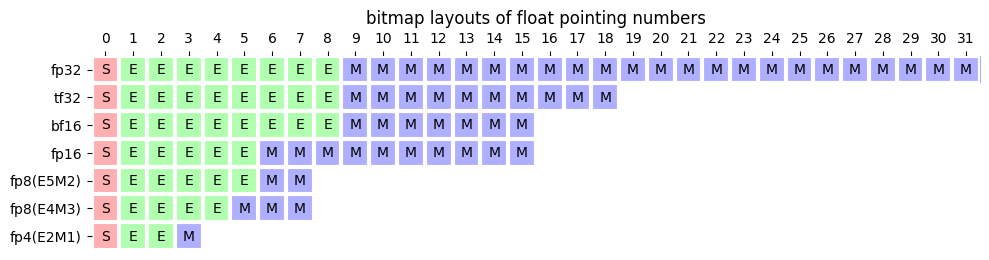

In [5]:
plot_float_formats(float_formats)

1. FP32: 1/8/23, 共 32 bit
2. TF32: 1/8 10, 共 19 bit
3. BF16: 1/8/7, 共 16 bit
4. FP16: 1/5/10, 共 16 bit
5. FP8有两种子格式：
    1. E5M2: 1/5/2, 共 8 bit
    2. E4M3: 1/4/3, 共 8 bit
6.  FP4: 1/2/1, 共 4 bit

## 量化方法

浮点数值的总bit数与内部bit布局的分配会极大的影响其动态范围，精度等特性[<sup>[1]</sup>](#fn1)。一个浮点数的数值可以表示为：
$$
(-1)^s \times 2^{e-bias} \times (1+\frac{1}{2^1}+\frac{1}{2^2}+\cdots+\frac{1}{2^m})
$$
其中：
1. $s \in \{0, 1\}$;
2. $e$ 为 指数位 所表达的整型数字，$bias=\frac{max(e)}{2}$;
3. $m$ 为 精度位 的个数

这里以FP8 E4M3为例，说明下如何计算。假设已经给了一个数值的浮点表达[0|0010|101]，根据前边所述的IEEE 754规范，其对应的数值的二进制表达为：
1. $s=0$
2. $e=0010$, $max(e)=1111$, $bias=111$
3. $m=101$

使用二进制计算浮点数值为：
$$
    (-1)^{s=0} \times 10^{0010-111} \times (1.101)
$$
换成十进制计算为：
$$
    (-1)^{0} \times 2^{2-11} \times (1+\frac{1}{2^1} + \frac{0}{2^2}+\frac{1}{2^3}) = 0.05078125
$$

## 特殊取值

### subnormal/normalized number

正常的浮点数中，一般不应该出现指数位全为0的情况，因为我们总是能够通过调整指数位,尽量让非零元素多一些，更充分利用整个动态范围和精度位。但实际上仍会出现指数位全为0的情况，我们称这种情况为**subnormal numbers**，反之则称为**normalized numbers**。
1. **subnormal numbers**: 指数位全为0，$(-1)^s \times 2^{-bias} \times 0.m$
2. **normalized numbers**: 指数位不全为0，$(-1)^s \times 2^{e-bias} \times (1+\frac{1}{2^1}+\frac{1}{2^2}+\cdots+\frac{1}{2^m})$

这里以FP8(E4M3)为例将数值的分布可视化出来，则能看到**normalized numbers**在坐标轴上呈对数分布，而**subnormal numbers**在坐标轴上呈线性分布。

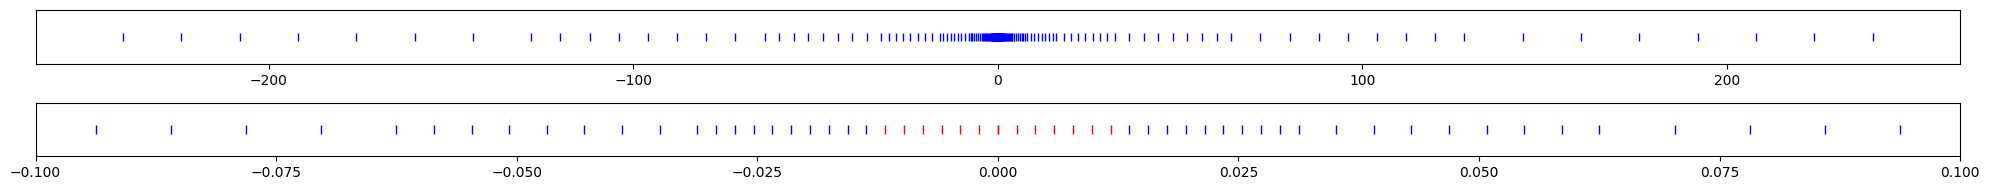

In [3]:
from float_point import float_point_values_table
fp8e4m3 = float_point_values_table(sign_bit=True, exponent_bits=4, mantissa_bits=3)
plt.figure(figsize=(20,2))
plt.subplot(2,1,1)
plt.scatter(fp8e4m3, [0 for x in fp8e4m3], c=["r" if abs(v)<0.013671875 else "b" for v in fp8e4m3], linewidths=1, marker="|")
# _ = plt.xlim(-10,10)
_ = plt.yticks([])
plt.tight_layout()

plt.subplot(2,1,2)
plt.scatter(fp8e4m3, [0 for x in fp8e4m3], c=["r" if abs(v)<0.013671875 else "b" for v in fp8e4m3], linewidths=1, marker="|")
_ = plt.xlim(-.1,.1)
_ = plt.yticks([])
plt.tight_layout()

仍以FP8（E4M3）为例，进一步分析下subnormal numbers对误差的影响：

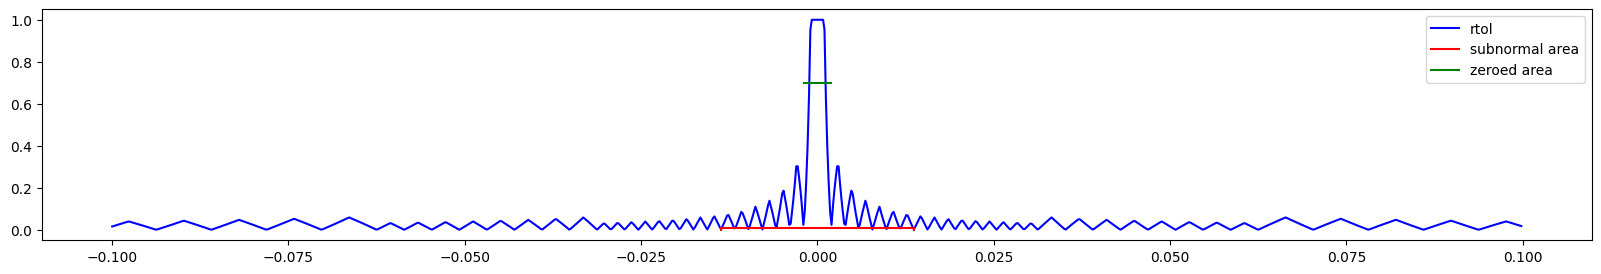

In [7]:
rng = 1E1
x = np.arange(-1./rng, 1./rng, 1/rng/5E5, dtype=np.float64)
y = torch.tensor(x).to(torch.float8_e4m3fn).to(torch.float64).numpy()
err = np.abs(x-y) / np.abs(x)
plt.figure(figsize=(20,3))
_=plt.plot(x[0::1000], err[0::1000], 'b', 
         [-0.013671875,-0.013671875,0.013671875,0.013671875], [0., 0.01, 0.01,0.], 'r',
        [-0.001953125,0.001953125], [0.7,0.7], 'g')
_=plt.legend(labels=["rtol", "subnormal area", "zeroed area"])

误差图说明：
1. 上图蓝色曲线为数轴上各点的相对量化误差($\frac{|数值-量化数值|}{数值}$);
2. 红色区间标识了subnormal number所在的区间；
3. 绿色曲线标识了FP8无法表示的区间，这个区间内的数值被量化成0；

一些观察到的现象：
1. subnormal number区间上，数值越小，相对量化误差不变，但绝对量化误差变大，最高接近40%；
2. normalied number区间上，量化误差不随数值空间有剧烈变化，整体在10%以内；
3. zeroed area上，量化误差100%；

一些评论：
1. 为啥需要loss scale？因为要尽可能让数值范围原理subnormal number区间；
2. 为啥loss scale问题比较难？如果loss scale过大，则会导致loss nan，若loss scale过小，则会导致梯度落入subnormal number区间，甚至落入zeroed area区间；

### INF与NAN
当指数位全部为1时，为特殊数值：
1. 若指数位全部为1，精度位全部为0，表示+/- INF;
2. 若指数位全部为1，精度位不全为0，表示NAN；

**INF和NAN何时产生**：
1. 上溢产生+INF，下溢产生-INF；
2. INF+INF=INF，（-INF）+（-INF）=-INF；
3. +INF + -INF = NAN

**INF与NAN对bit效率的影响**：
由于NAN和INF有多个二进制表达，而这些表达都要占用可用编码空间。我们可以通过对比浮点数的value table来观察NAN对bit效率的影响。

In [8]:
display(Markdown("**FP4(E2M1)**\n\n----"))
_=float_point_values_table(True, 2, 1, draw=True)
display(Markdown("**FP4(E1M2)**\n\n----"))
_=float_point_values_table(True, 1, 2, draw=True)


**FP4(E2M1)**

----

| |… 0|… 1|
|---|---|---|
|0 00 …|0.0|0.5|
|0 01 …|1.0|1.5|
|0 10 …|2.0|3.0|
|0 11 …|Inf|NaN|
|1 00 …|-0.0|-0.5|
|1 01 …|-1.0|-1.5|
|1 10 …|-2.0|-3.0|
|1 11 …|-Inf|-NaN|


**FP4(E1M2)**

----

| |… 00|… 01|… 10|… 11|
|---|---|---|---|---|
|0 0 …|0.0|0.5|1.0|1.5|
|0 1 …|Inf|NaN|NaN|NaN|
|1 0 …|-0.0|-0.5|-1.0|-1.5|
|1 1 …|-Inf|-NaN|-NaN|-NaN|


对比FP4(E2M1)与FP4(E1M2)的value table，可以看到：
1. 4bit总共有16个有效表达；
2. E2M1有12个数字，4个INF+NAN；
3. E1M2只有8个数字，8个INF+NAN；

由于IEEE 754的定义，精度位越多，则NAN的二进制表达越多，bit效率就越低。这种bit效率问题在16位浮点中并不明显，但在8bit和4bit中则不得不进行考虑。若使用$\frac{有效编码空间}{总编码空间}$来衡量bit效率，可以看到常见的几种数值格式的编码效率如下：

1. FP32 = $\frac{2^{32}-2\times2^{23}}{2^{32}}$ = 99.61%
2. BF16 = $\frac{2^{16}-2\times2^{7}}{2^{16}}$ = 99.61%
3. BF16 = $\frac{2^{16}-2\times2^{10}}{2^{16}}$ = 96.88%
4. FP8(E5M2) = $\frac{2^{8}-2\times2^{2}}{2^{8}}$ = 96.88%
5. FP8(E4M3) = $\frac{2^{8}-2\times2^{3}}{2^{8}}$ = 93.75%
6. FP4(E2M1) = $\frac{2^{4}-2\times2^{1}}{2^{4}}$ = 75%
7. FP4(E1M2) = $\frac{2^{4}-2\times2^{2}}{2^{4}}$ = 50%

对16bit及以上精度的浮点格式，bit效率问题可以忽略不计，对8bit及以下的数值格式，NAN引入的bit效率问题急剧恶化，不得不引起重视。

TODO：进一步调研NVidia的FP4和FP6方案，以及对INF与NAN的定义是否与标准的IEEE 754有所出入。

## 特殊性质与指标

# 量化误差分析

## 数值误差分析

在前边一节中，我们对subnormal number的量化误差进行了分析。在本节将会就浮点类型量化误差的性质进行更一般的分析。首先看一下$[-100,100]$区间上float16数据类型的绝对误差和相对误差。

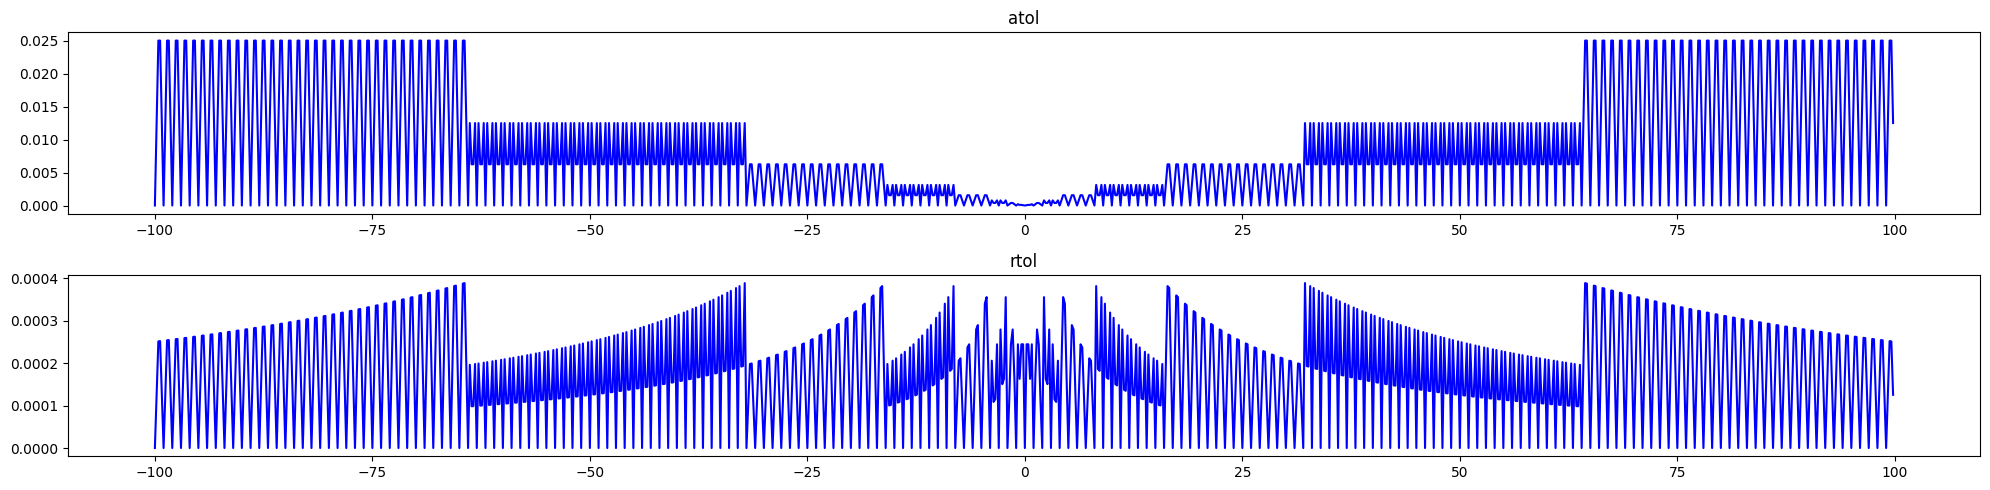

In [9]:
x = np.arange(-100., 100., 200./1E6, dtype=np.float64)
y = torch.tensor(x).to(torch.float16).to(torch.float64).numpy()

fp16_atol = np.abs(x-y) #/ np.abs(x)
fp16_rtol = np.abs(x-y) / np.abs(x)
fp16_rtol[np.argmax(fp16_rtol)] = 0.

plt.figure(figsize=(20,5))
plt.subplot(2,1,1)
plt.plot(x[0::1000], fp16_atol[0::1000], 'b')
plt.title("atol")
plt.subplot(2,1,2)
plt.plot(x[0::1000], fp16_rtol[0::1000], 'b')
plt.title("rtol")
plt.tight_layout()

上图为绝对误差，可以看到随着绝对值的增大，绝对误差也逐步翻倍增大，但下图中的相对误差一直保持在0.04%以下。绝对误差翻倍的位置就是浮点表示中指数位发生变化的位置。

接下来看下bfloat16格式在相同区间上的误差分布：

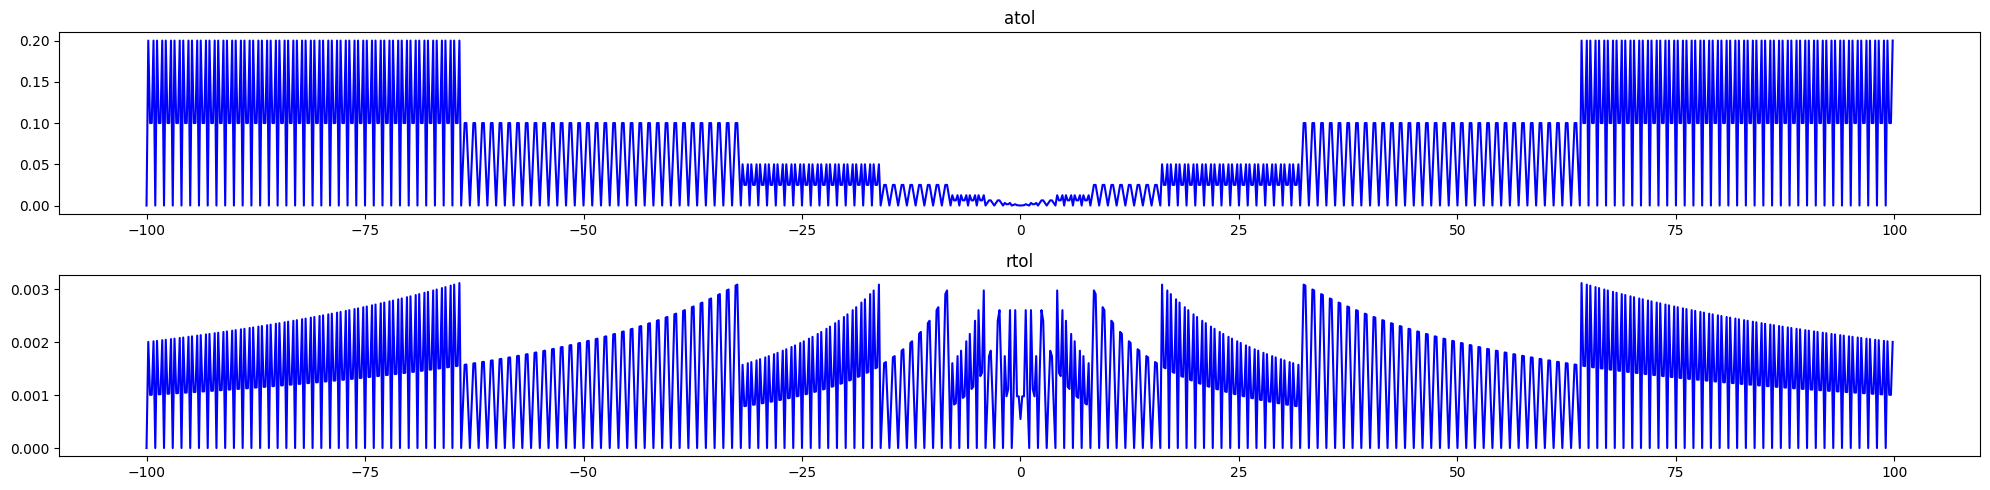

In [10]:
x = np.arange(-100., 100., 200./1E6, dtype=np.float64)
y = torch.tensor(x).to(torch.bfloat16).to(torch.float64).numpy()

bf16_atol = np.abs(x-y) #/ np.abs(x)
bf16_rtol = np.abs(x-y) / np.abs(x)
bf16_rtol[np.argmax(bf16_rtol)] = 0.

plt.figure(figsize=(20,5))
plt.subplot(2,1,1)
plt.plot(x[0::1000], bf16_atol[0::1000], 'b')
plt.title("atol")
plt.subplot(2,1,2)
plt.plot(x[0::1000], bf16_rtol[0::1000], 'b')
plt.title("rtol")
plt.tight_layout()

In [11]:
display(Markdown(f"""
对比float16和bfloat16

|  | float16 | bfloat16 |
|--| --------|----------|
|atol| {fp16_atol.max()} | {bf16_atol.max()}|
|rtol| {fp16_rtol.max()} | {bf16_rtol.max()} |
"""))


对比float16和bfloat16

|  | float16 | bfloat16 |
|--| --------|----------|
|atol| 0.031200006636197486 | 0.2500000066144139|
|rtol| 0.0004872627000076852 | 0.003891050668191725 |


无论是atol还是rtol，bfloat16都远高于fp16。但是该结论对于深度学习的推理和训练来讲借鉴意义不大，因为深度学习中的权重和激活值的分布都在0附近。因此我们进一步通过一个高斯噪声来观察两种数值的误差情况。

首先通过随机采样的方式取一个0附近的高斯分布：

In [12]:
x = .0001*np.random.randn(100000)
x = np.sort(x)

接下来先看float16的误差分布：

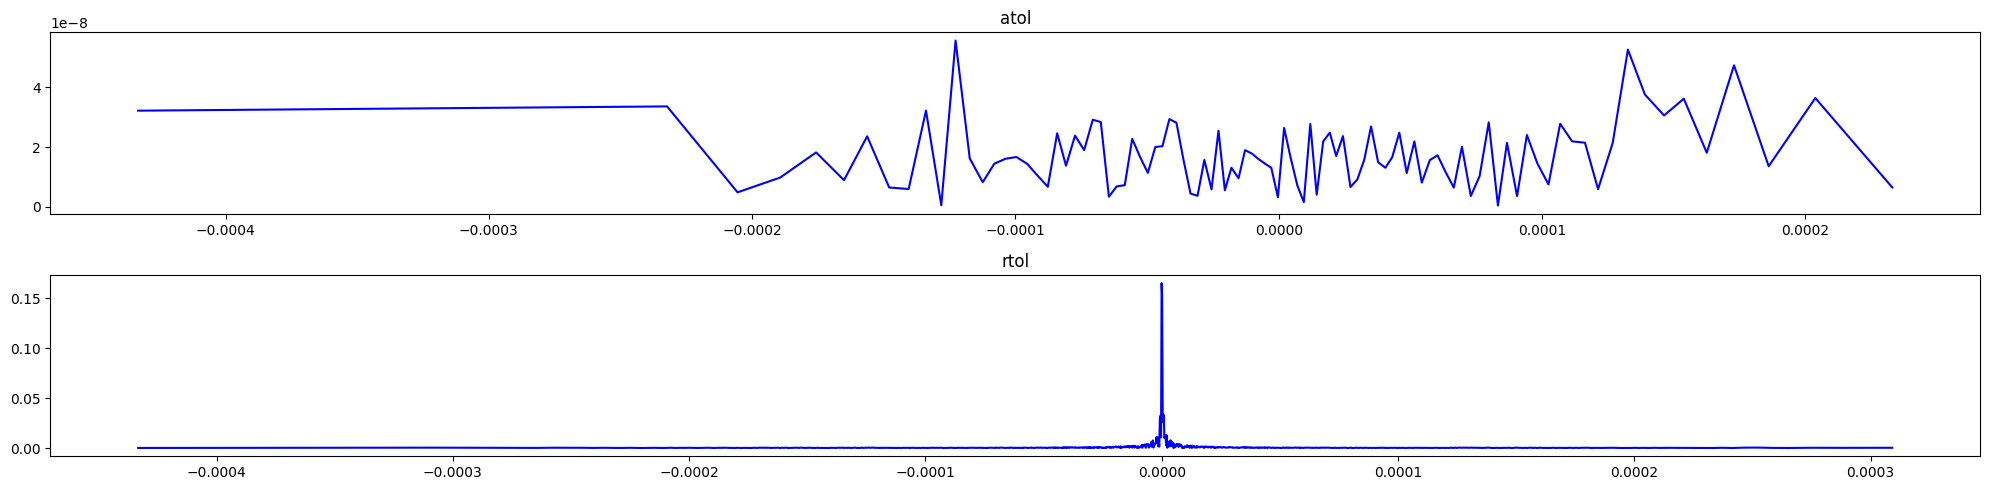

In [13]:
y = torch.tensor(x).to(torch.float16).to(torch.float64).numpy()

fp16_atol = np.abs(x-y) #/ np.abs(x)
fp16_rtol = np.abs(x-y) / np.abs(x)
fp16_rtol[fp16_rtol==1.] = 0.

plt.figure(figsize=(20,5))
plt.subplot(2,1,1)
plt.plot(x[0::1000], fp16_atol[0::1000], 'b')
plt.title("atol")
plt.subplot(2,1,2)
plt.plot(x[0::100], fp16_rtol[0::100], 'b')
plt.title("rtol")
plt.tight_layout()

在看bfloat16的误差分布：

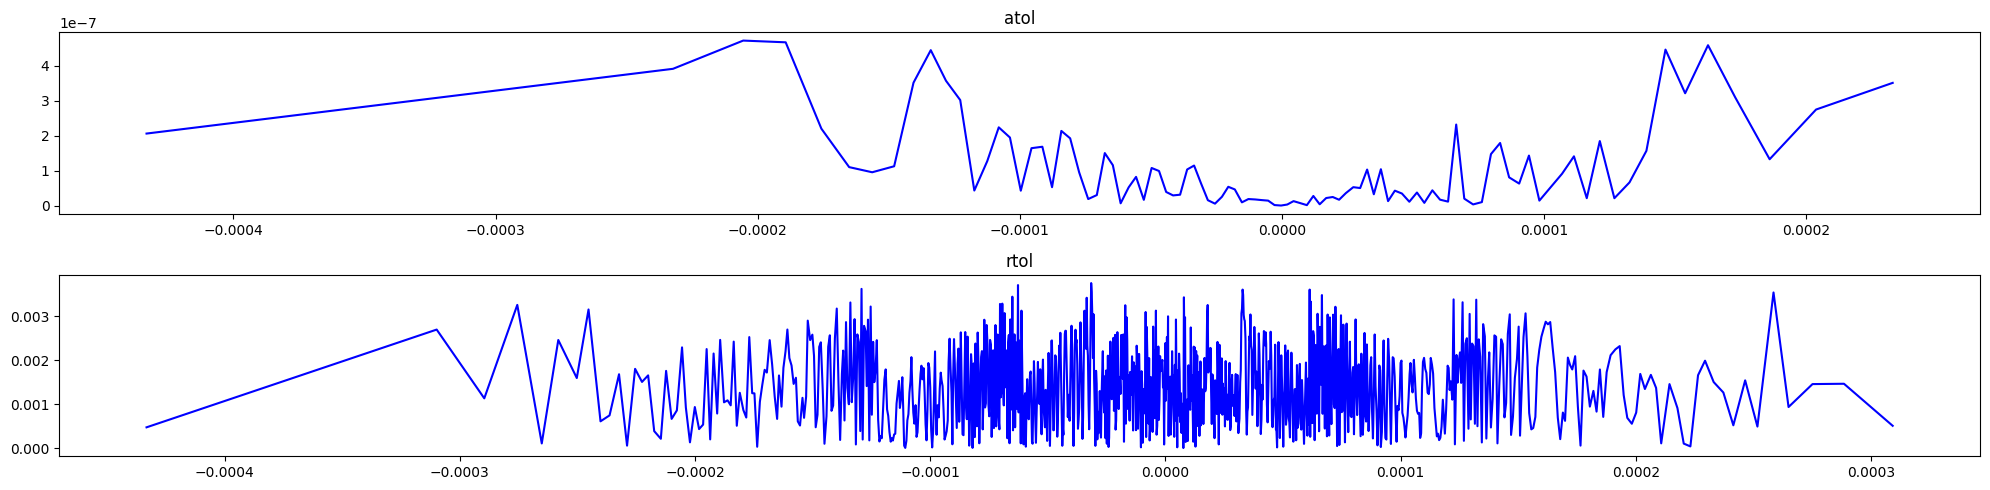

In [14]:
y = torch.tensor(x).to(torch.bfloat16).to(torch.float64).numpy()

bf16_atol = np.abs(x-y) #/ np.abs(x)
bf16_rtol = np.abs(x-y) / np.abs(x)
bf16_rtol[bf16_rtol==1.] = 0.

plt.figure(figsize=(20,5))
plt.subplot(2,1,1)
plt.plot(x[0::1000], bf16_atol[0::1000], 'b')
plt.title("atol")
plt.subplot(2,1,2)
plt.plot(x[0::100], bf16_rtol[0::100], 'b')
plt.title("rtol")
plt.tight_layout()

对比两者，我们发现bfloat16在0附近的绝对误差更显，并且相对误差稳定在0.4%附近，而float16的相对误差最大达到20%以上。因此在大模型训练的过程中，bfloat16能够提供更好的数值稳定性。

TODO：是否LNS对数数值系统在0附近能够提供更好的数值稳定性？？需要后边设计一些实验来进行证明。

## 运算误差分析

In [81]:
x = float_point_values_table(True, 4, 3, False)

In [102]:
def show_map(xx, name, limit):
    cm = ((xx > 240) | (xx < -240)) *0.25 + \
        (np.abs(xx) <=0.013671875) * 0.5 + \
        (np.abs(xx) < 0.001953125) *0.25 + \
        (xx == 32)*1.0 + (xx == -32)*1.0 + \
        (xx == 4)*1.0 + (xx == -4)*1.0 + \
        (xx == .5)*1.0 + (xx == -.5)*1.0 + \
        (xx == 0.0625)*1.0 + (xx == -0.0625)*1.0
    plt.imshow(cm,cmap=matplotlib.colors.ListedColormap(["#00ff0050", "#ff000080", "#0000ff80","#000000FF","#f000f080"]))
    plt.title(name)

def show_map2(xx, name, limit):
    xl = [[q for q in x] for p in x]
    yl = [[p for q in x] for p in x]
    cm = ((xx > 240) | (xx < -240)) *0.25 + \
        (np.abs(xx) <=0.013671875) * 0.5 + \
        (np.abs(xx) < 0.001953125) *0.25 + \
        (xx == 32)*1.0 + (xx == -32)*1.0 + \
        (xx == 4)*1.0 + (xx == -4)*1.0 + \
        (xx == .5)*1.0 + (xx == -.5)*1.0 + \
        (xx == 0.0625)*1.0 + (xx == -0.0625)*1.0
    plt.scatter(xl, yl, c=cm, 
                linewidths=.5,
                marker='.',
                cmap=matplotlib.colors.ListedColormap(["#00ff0050", "#ff000080", "#0000ff80","#000000FF","#f000f080"]))
    plt.scatter(xl, yl, c=cm, 
            s = ((xx > 240) | (xx < -240)) *2 + (np.abs(xx) <=0.013671875) * 3,
            linewidths=1,
            marker='.',
            cmap=matplotlib.colors.ListedColormap(["#00ff0050", "#ff000080", "#0000ff80","#000000FF","#f000f080"]))
    if limit is not None:
        plt.xlim(limit)
        plt.ylim(limit)
    plt.title(name)
    
def plot_basic_op_map(x, show_fn, limit=None):
    plt.figure(figsize=(20,20))

    plt.subplot(2,2,1)
    xx = np.array([[p+q for q in x] for p in x])
    show_fn(xx, "A+B", limit)
    
    plt.subplot(2,2,2)
    xx = np.array([[p-q for q in x] for p in x])
    show_fn(xx, "A-B", limit)
    
    plt.subplot(2,2,3)
    xx = np.array([[p*q for q in x] for p in x])
    show_fn(xx, "AxB", limit)
    
    plt.subplot(2,2,4)
    xx = np.array([[p/q if q != 0 else 1E10 for q in x] for p in x])
    show_fn(xx, "A / B", limit)
    
    plt.tight_layout()

FP8 E4M3 总共有240种不同的取值，我们首先看下这240种取值的加减乘除操作的结果。下图中横轴为A，纵轴为B。绿色趋于为Normalied Number对应的区域，红色区域为+/-INF对应的趋于，蓝色趋于为Subnormal Number对应的区域，黑色趋于表示数值过小无法表示的区域。为了更好的观察空间结构，用紫色线条表示了一些特定数值[32,4,0.5,0.0625]

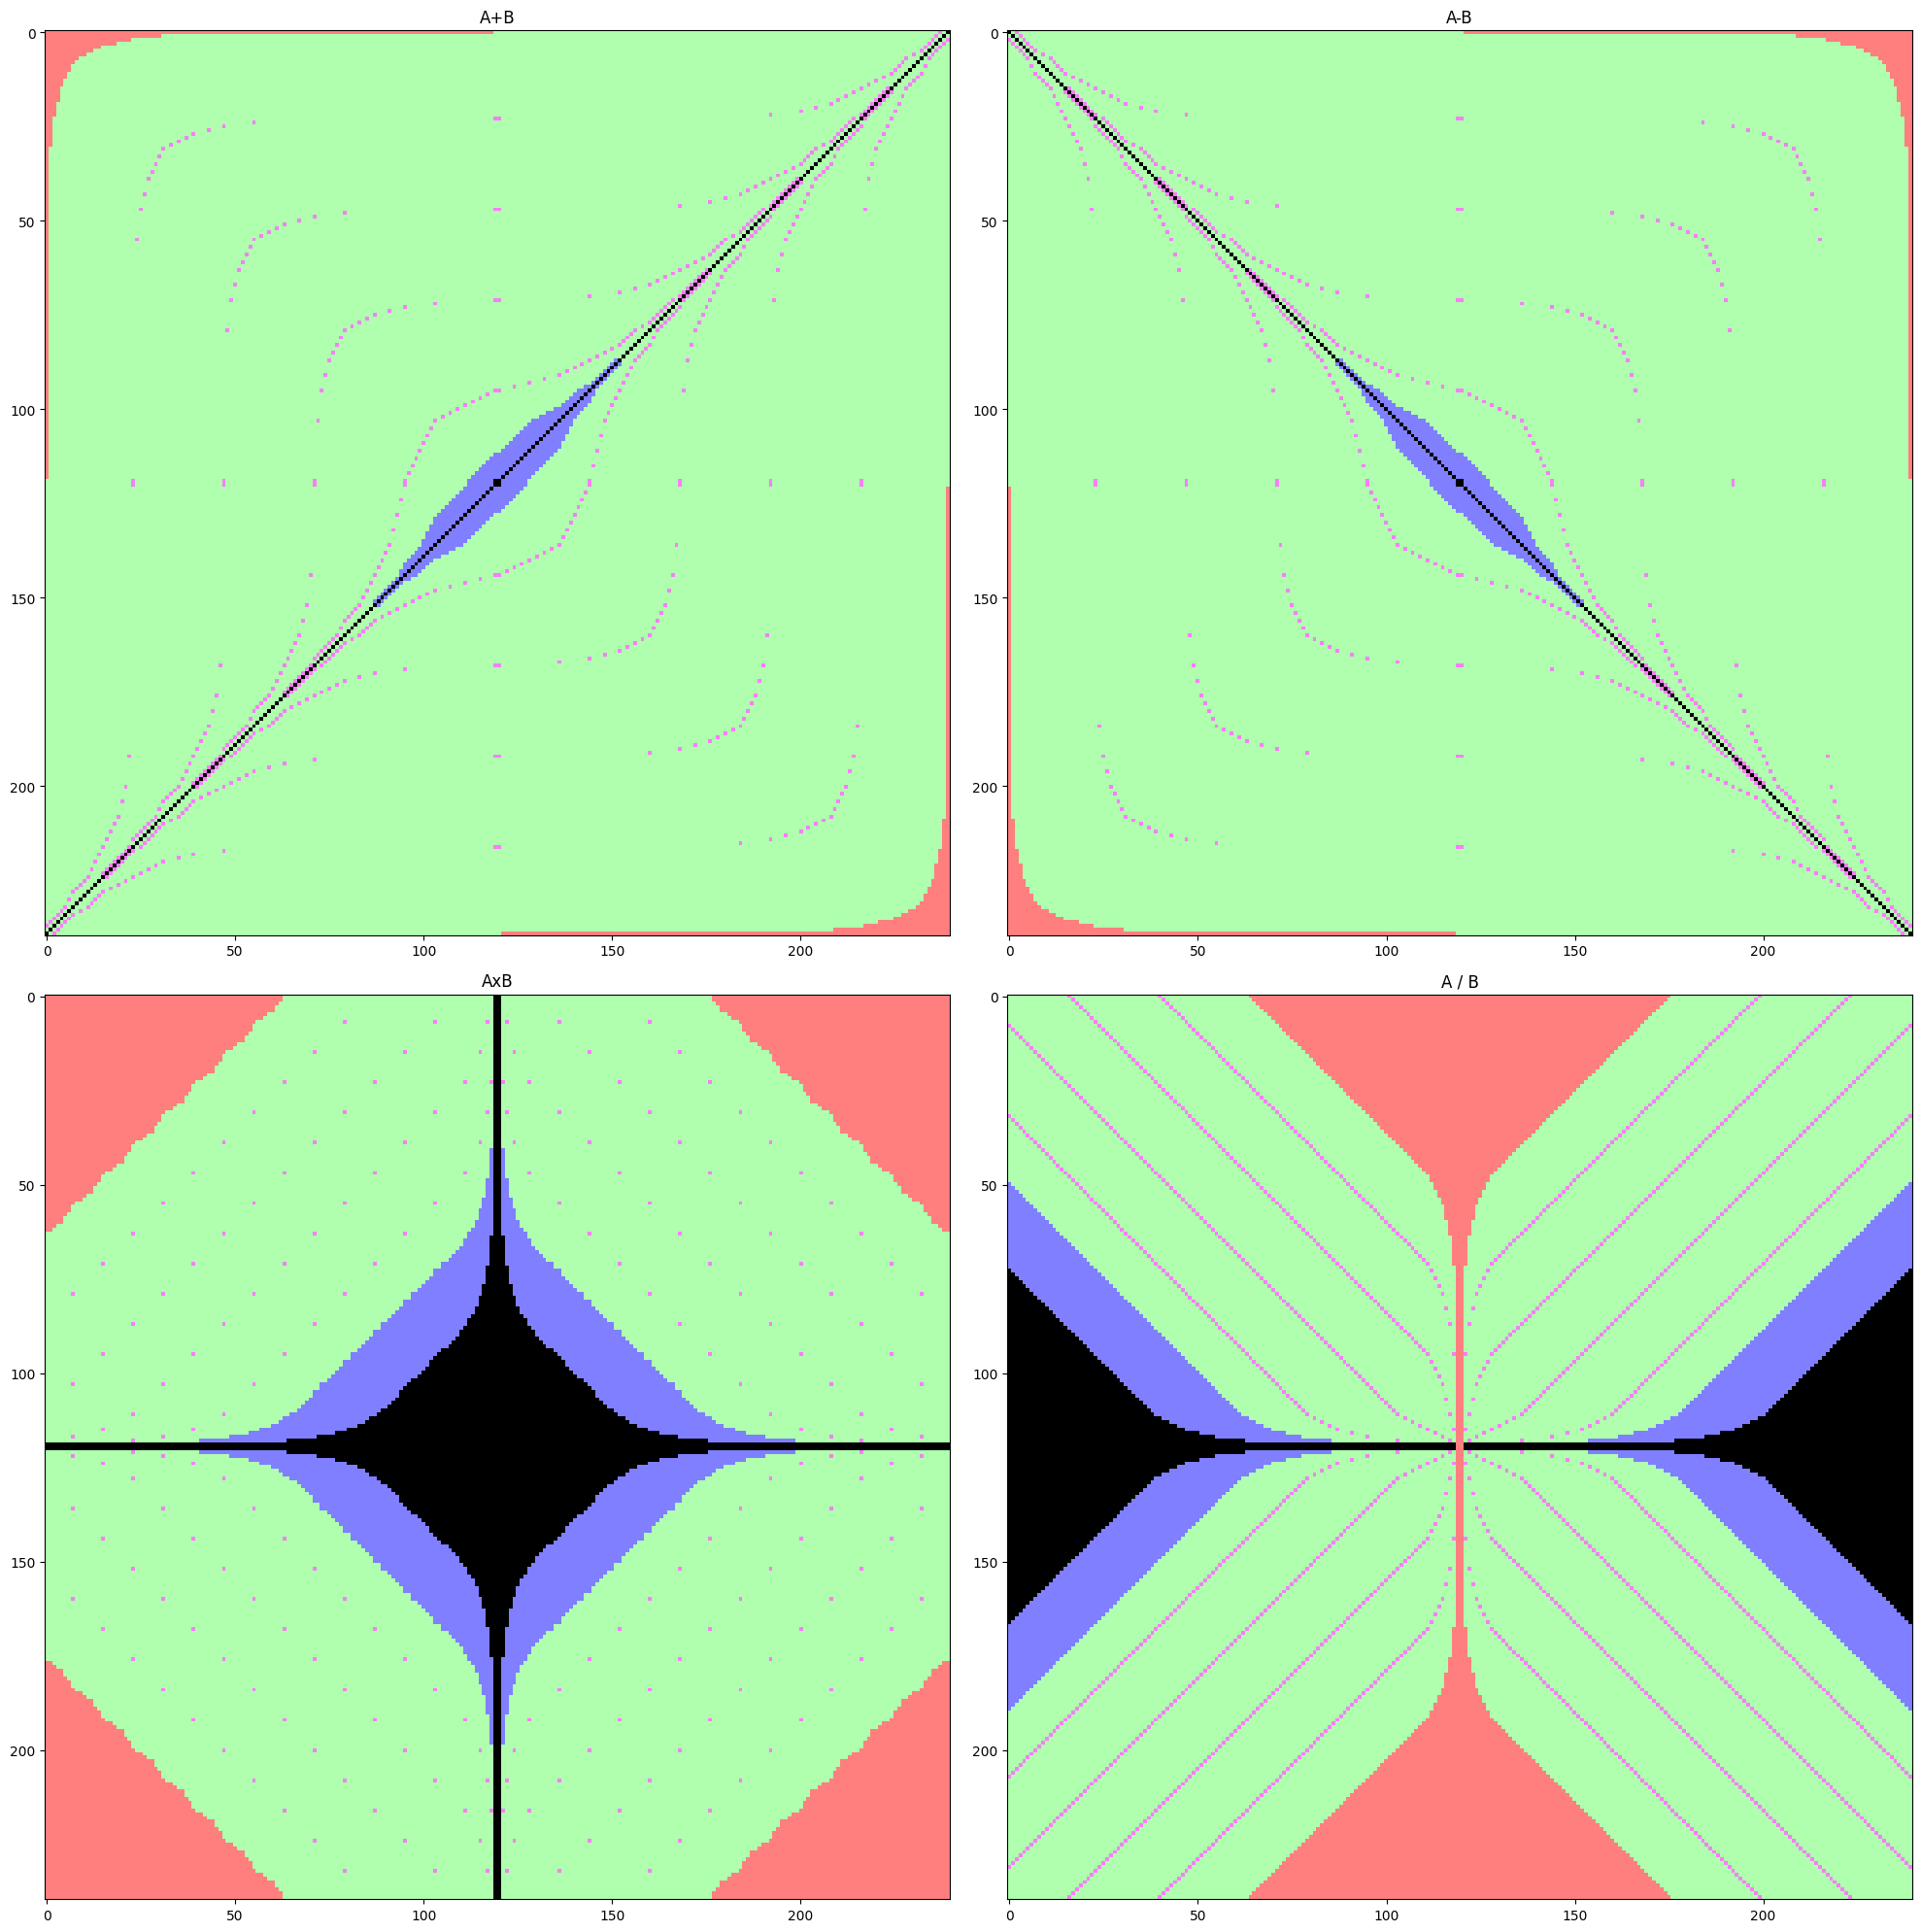

In [85]:
plot_basic_op_map(x, show_map)

从上图可见，+/-操作结果空间上，绿色趋于非常大，也就意味着大多数时候计算结果都是正常结果。而乘除法操作结果空间上，非常大的空间被蓝色（Submormal）、黑色（Zeroed）与红色（+/- INF）占据(共约约1/4的空间)。

由于浮点数在数轴上呈log分布，上图不能反应在实际线性数值空间上，结果的分布情况，因此我们重新在实际数值坐标轴上重新绘制结果空间

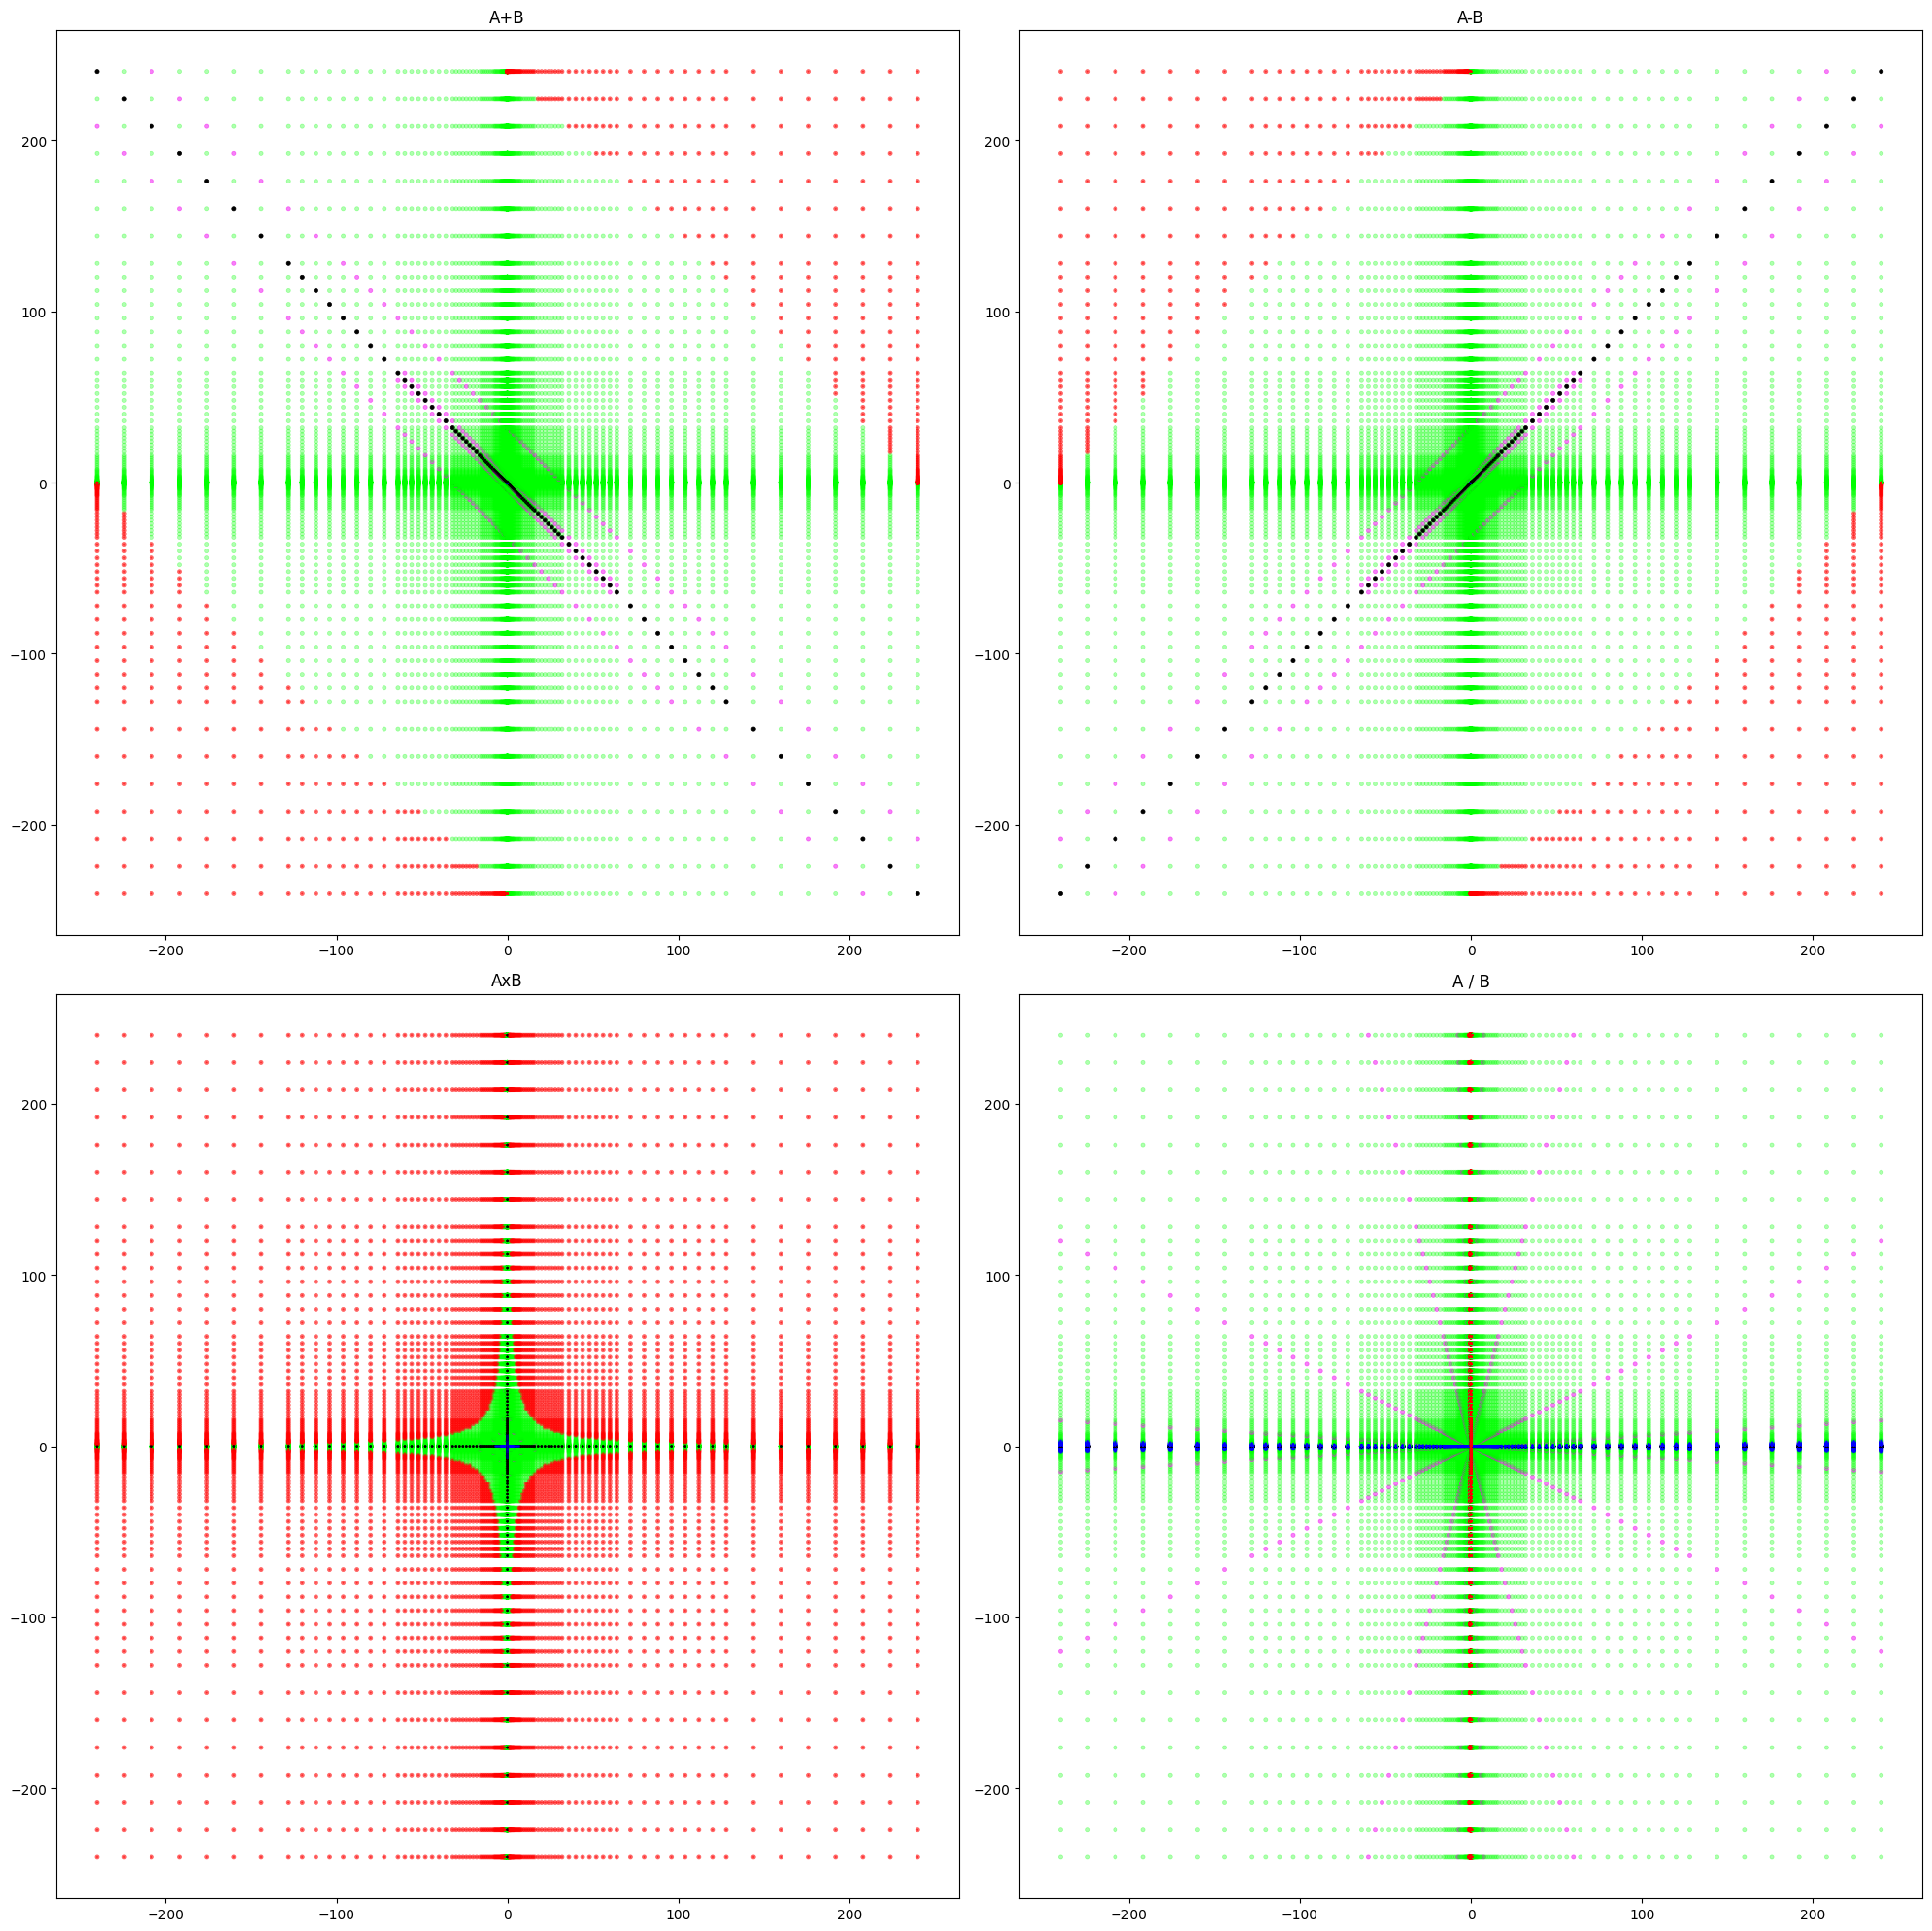

In [103]:
plot_basic_op_map(x, show_map2)

在实际数轴上，由于浮点数分布的不均衡性，我们看到：
1. 对加减法来说，大约3/4数值空间是稳定的；
2. 对于乘法来说，大多数数据空间都是不稳定的，只有0附近才能保证结果稳定；
3. 对出发来说，大多数数值空间都是稳定的；

如果仅从上述结果来看，FP8精度的数值稳定性相当糟糕，极为不稳定。但考虑到深度学习中权重和激活值大多数都处于0附近，我们也限制操作数的取值再次实验：

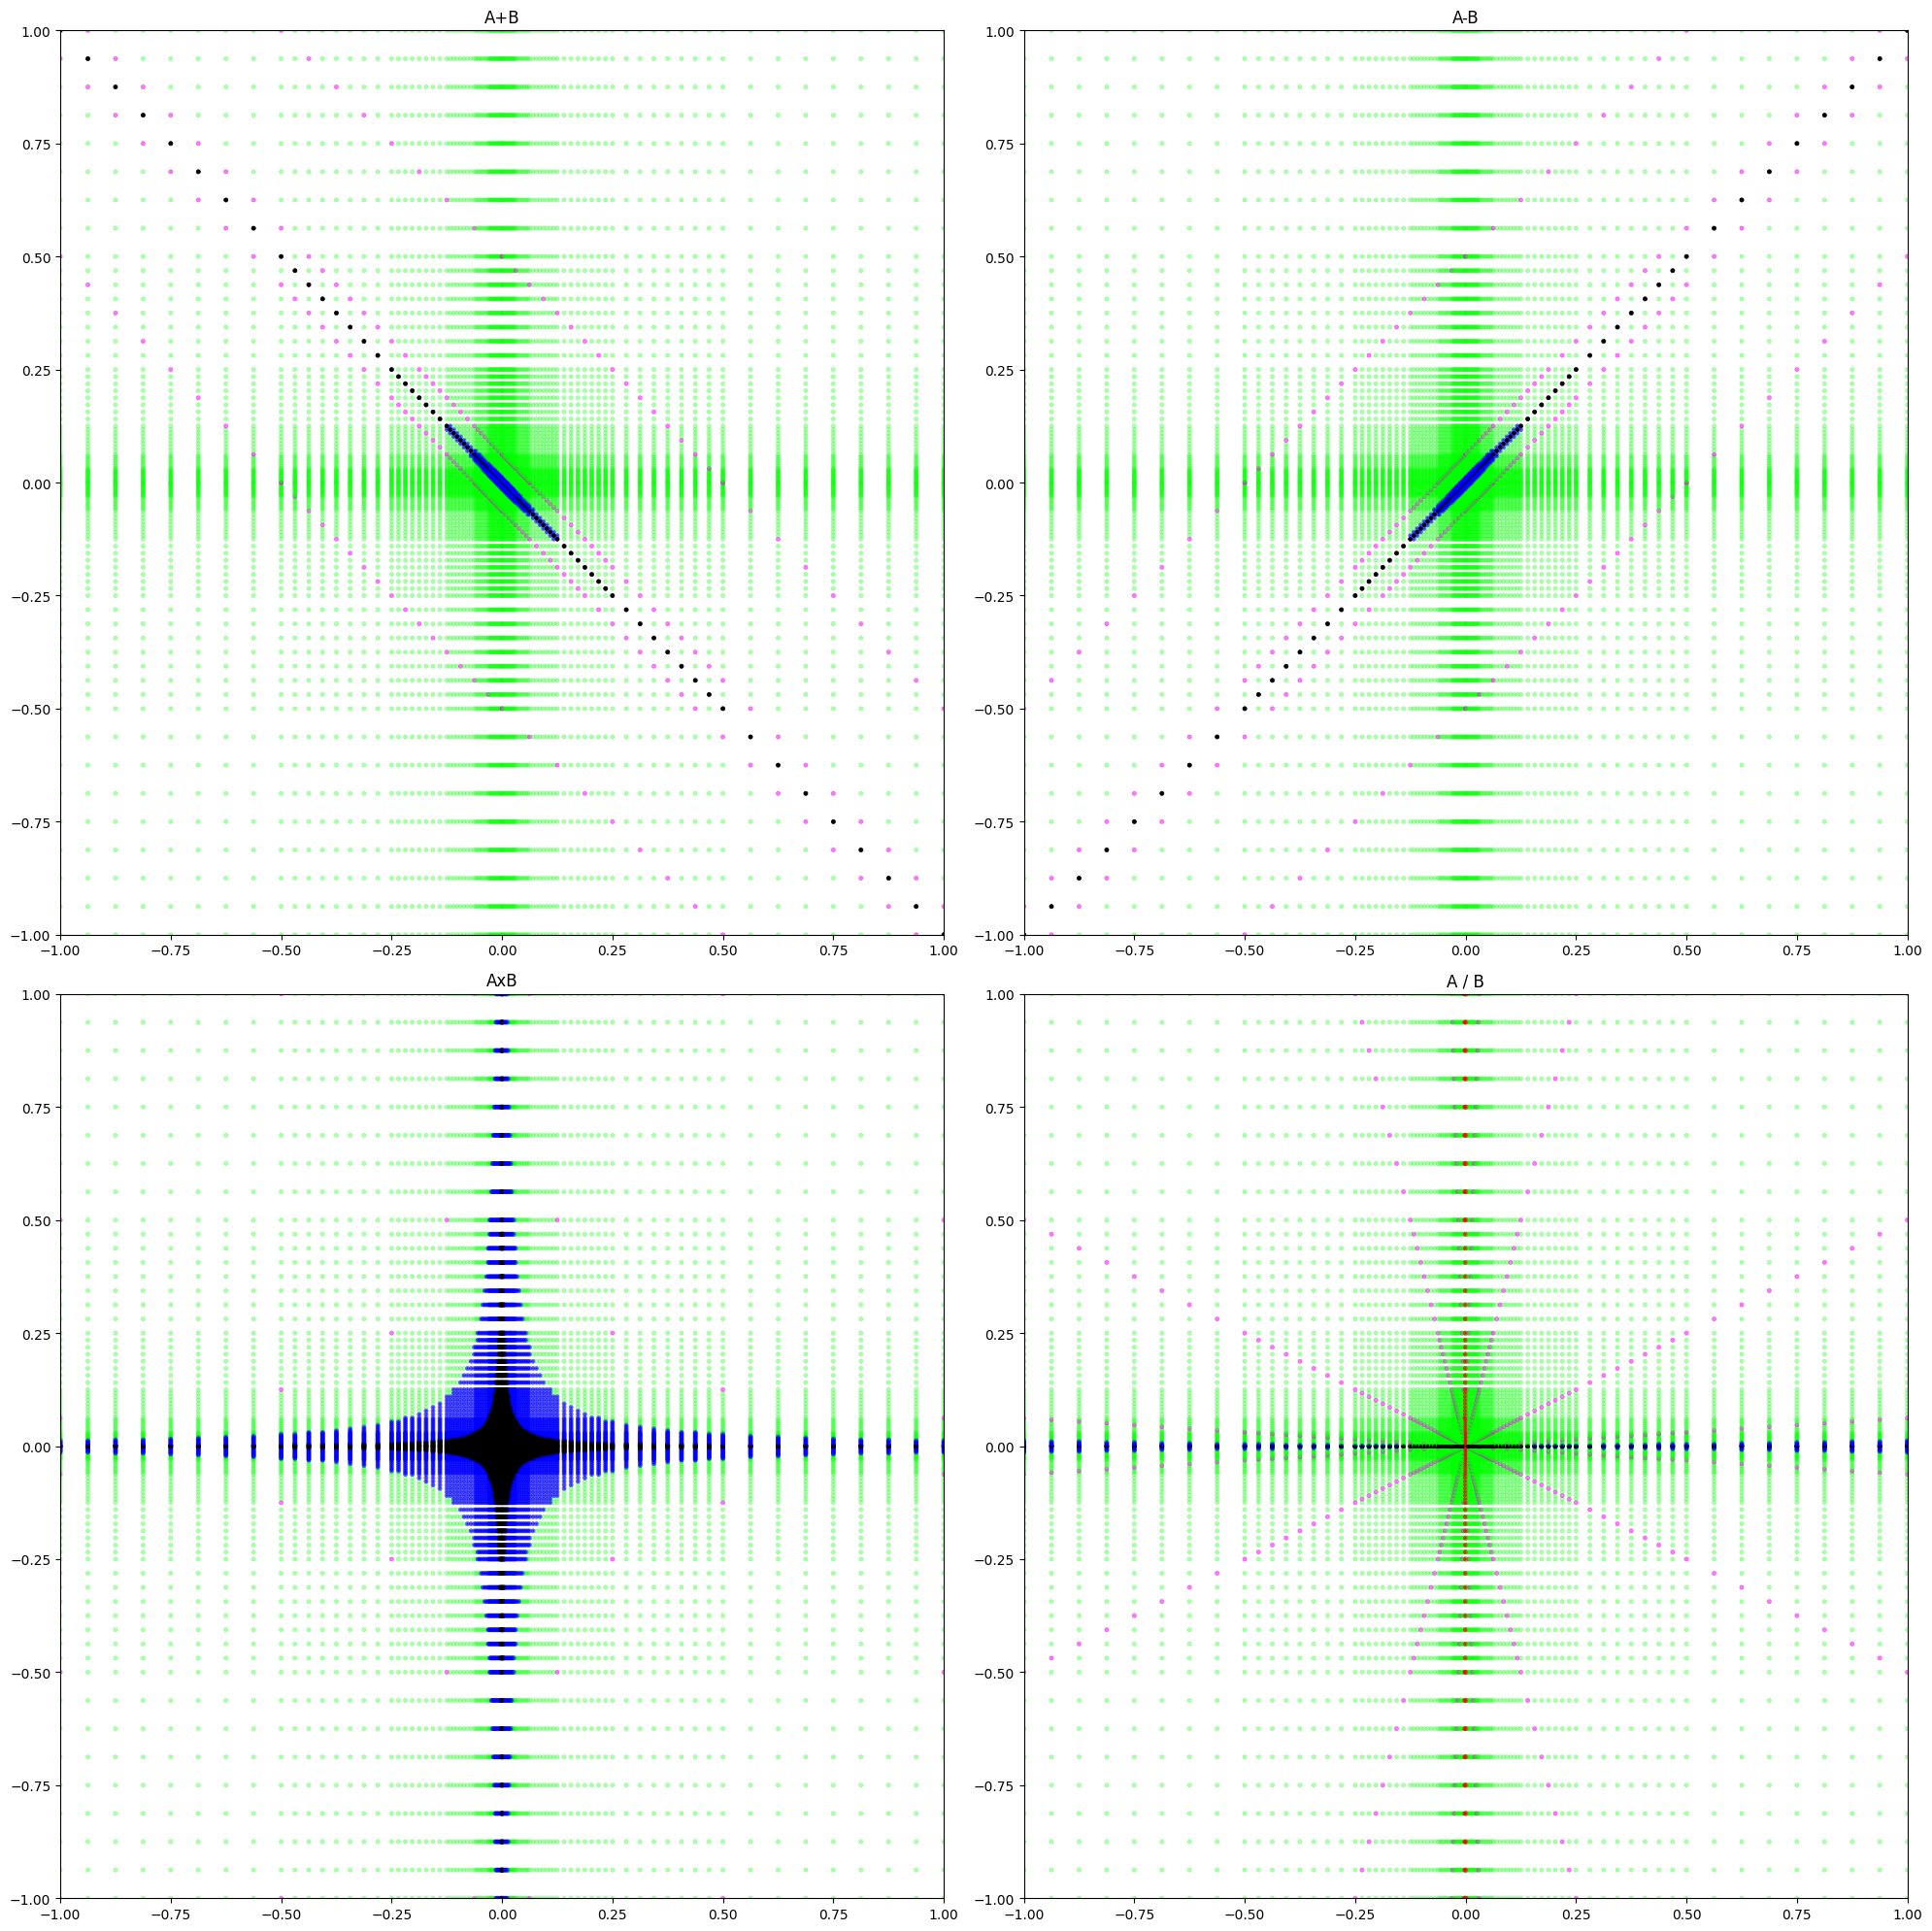

In [104]:
plot_basic_op_map(x, show_map2, limit=[-1,1])

可以看到，若输入限定在[-1,+1]之间，则可以避免大多数不稳定的情况。值得注意的是乘法操作非常容易首Submormal numbers误差高的问题影响。若进一步缩减表达范围到[-0.1,+0.1]，则有：

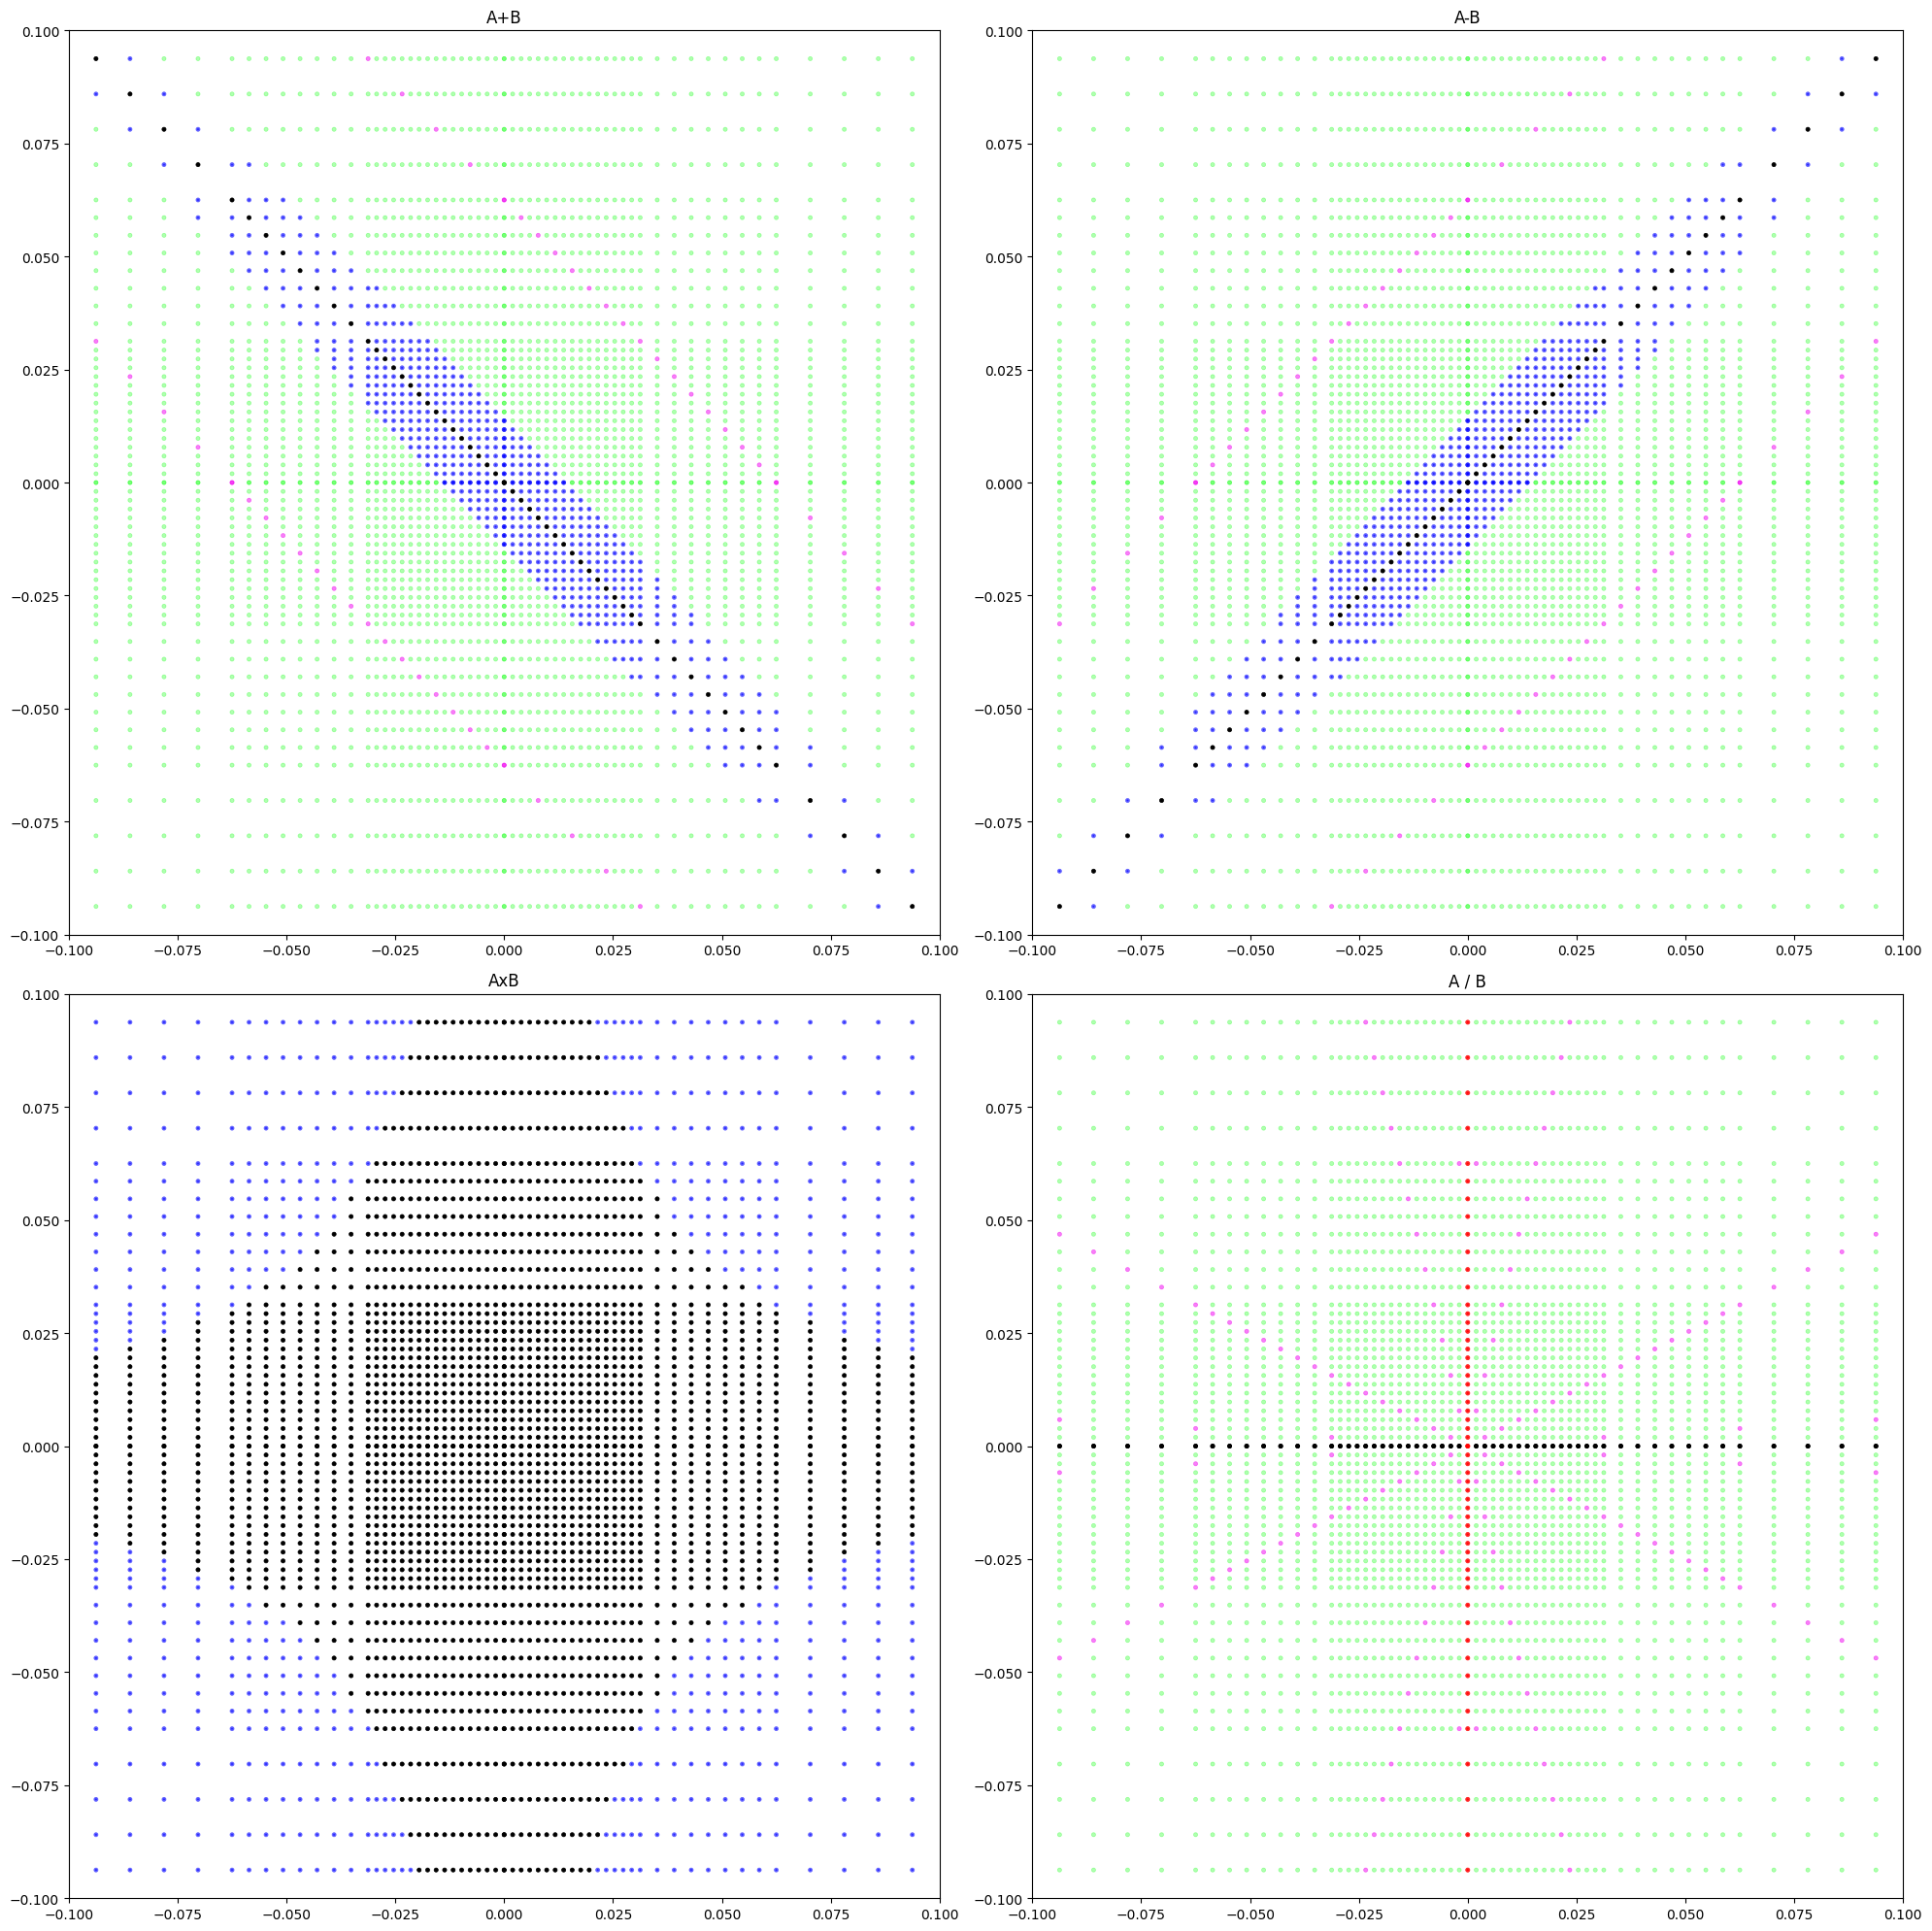

In [105]:
plot_basic_op_map(x, show_map2, limit=[-.1,.1])

整个乘法操作的解空间都收subnormal和zeroed数值的影响。这也是为何FP8必须配合pre-tensor scale才能使用。

In [109]:
x = float_point_values_table(True, 5, 2, False)

In [108]:
def show_map(xx, name, limit):
    cm = ((xx > 57344.0) | (xx < -57344.0)) *0.25 + \
        (np.abs(xx) <=4.57763671875e-05) * 0.5 + \
        (np.abs(xx) < 1.52587890625e-05) *0.25 + \
        (xx == 32)*1.0 + (xx == -32)*1.0 + \
        (xx == 4)*1.0 + (xx == -4)*1.0 + \
        (xx == .5)*1.0 + (xx == -.5)*1.0 + \
        (xx == 0.0625)*1.0 + (xx == -0.0625)*1.0
    plt.imshow(cm,cmap=matplotlib.colors.ListedColormap(["#00ff0050", "#ff000080", "#0000ff80","#000000FF","#f000f080"]))
    plt.title(name)

def show_map2(xx, name, limit):
    xl = [[q for q in x] for p in x]
    yl = [[p for q in x] for p in x]
    cm = ((xx > 57344.0) | (xx < -57344.0)) *0.25 + \
        (np.abs(xx) <=4.57763671875e-05) * 0.5 + \
        (np.abs(xx) < 1.52587890625e-05) *0.25 + \
        (xx == 32)*1.0 + (xx == -32)*1.0 + \
        (xx == 4)*1.0 + (xx == -4)*1.0 + \
        (xx == .5)*1.0 + (xx == -.5)*1.0 + \
        (xx == 0.0625)*1.0 + (xx == -0.0625)*1.0
    plt.scatter(xl, yl, c=cm, 
                linewidths=.5,
                marker='.',
                cmap=matplotlib.colors.ListedColormap(["#00ff0050", "#ff000080", "#0000ff80","#000000FF","#f000f080"]))
    plt.scatter(xl, yl, c=cm, 
            s = ((xx > 240) | (xx < -240)) *2 + (np.abs(xx) <=0.013671875) * 3,
            linewidths=1,
            marker='.',
            cmap=matplotlib.colors.ListedColormap(["#00ff0050", "#ff000080", "#0000ff80","#000000FF","#f000f080"]))
    if limit is not None:
        plt.xlim(limit)
        plt.ylim(limit)
    plt.title(name)
    
def plot_basic_op_map(x, show_fn, limit=None):
    plt.figure(figsize=(20,20))

    plt.subplot(2,2,1)
    xx = np.array([[p+q for q in x] for p in x])
    show_fn(xx, "A+B", limit)
    
    plt.subplot(2,2,2)
    xx = np.array([[p-q for q in x] for p in x])
    show_fn(xx, "A-B", limit)
    
    plt.subplot(2,2,3)
    xx = np.array([[p*q for q in x] for p in x])
    show_fn(xx, "AxB", limit)
    
    plt.subplot(2,2,4)
    xx = np.array([[p/q if q != 0 else 1E10 for q in x] for p in x])
    show_fn(xx, "A / B", limit)
    
    plt.tight_layout()

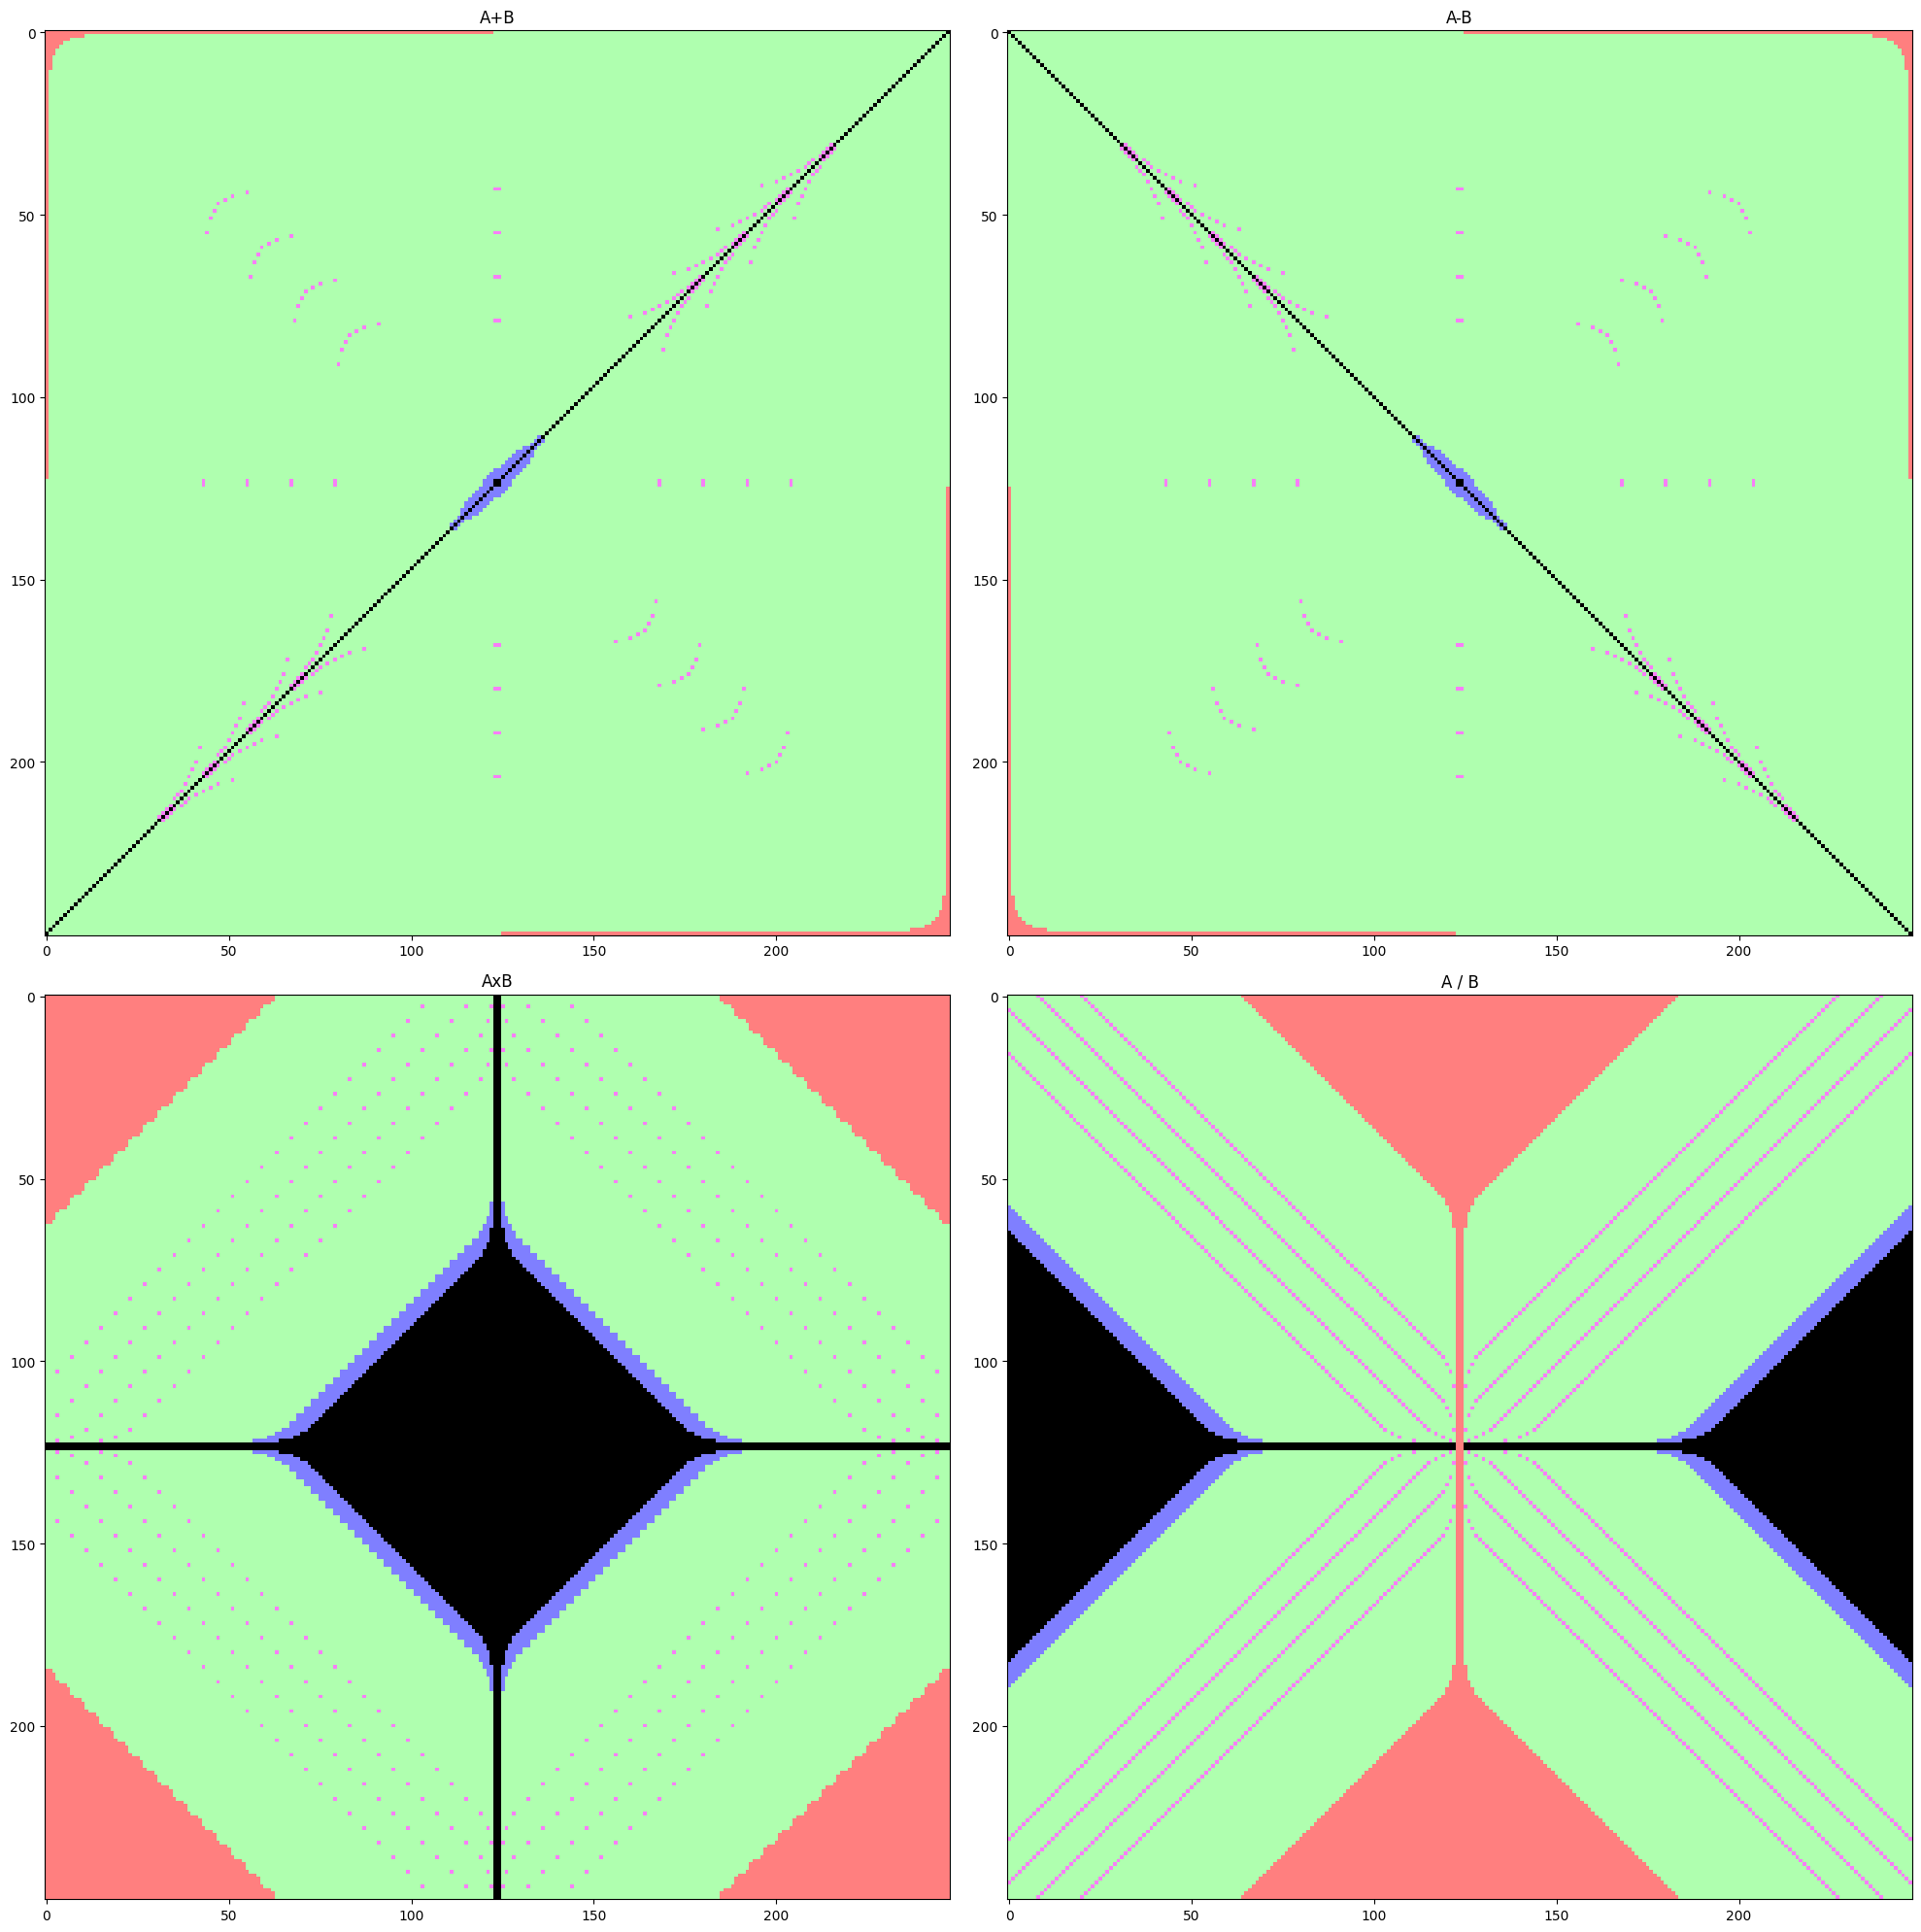

In [110]:
plot_basic_op_map(x, show_map)

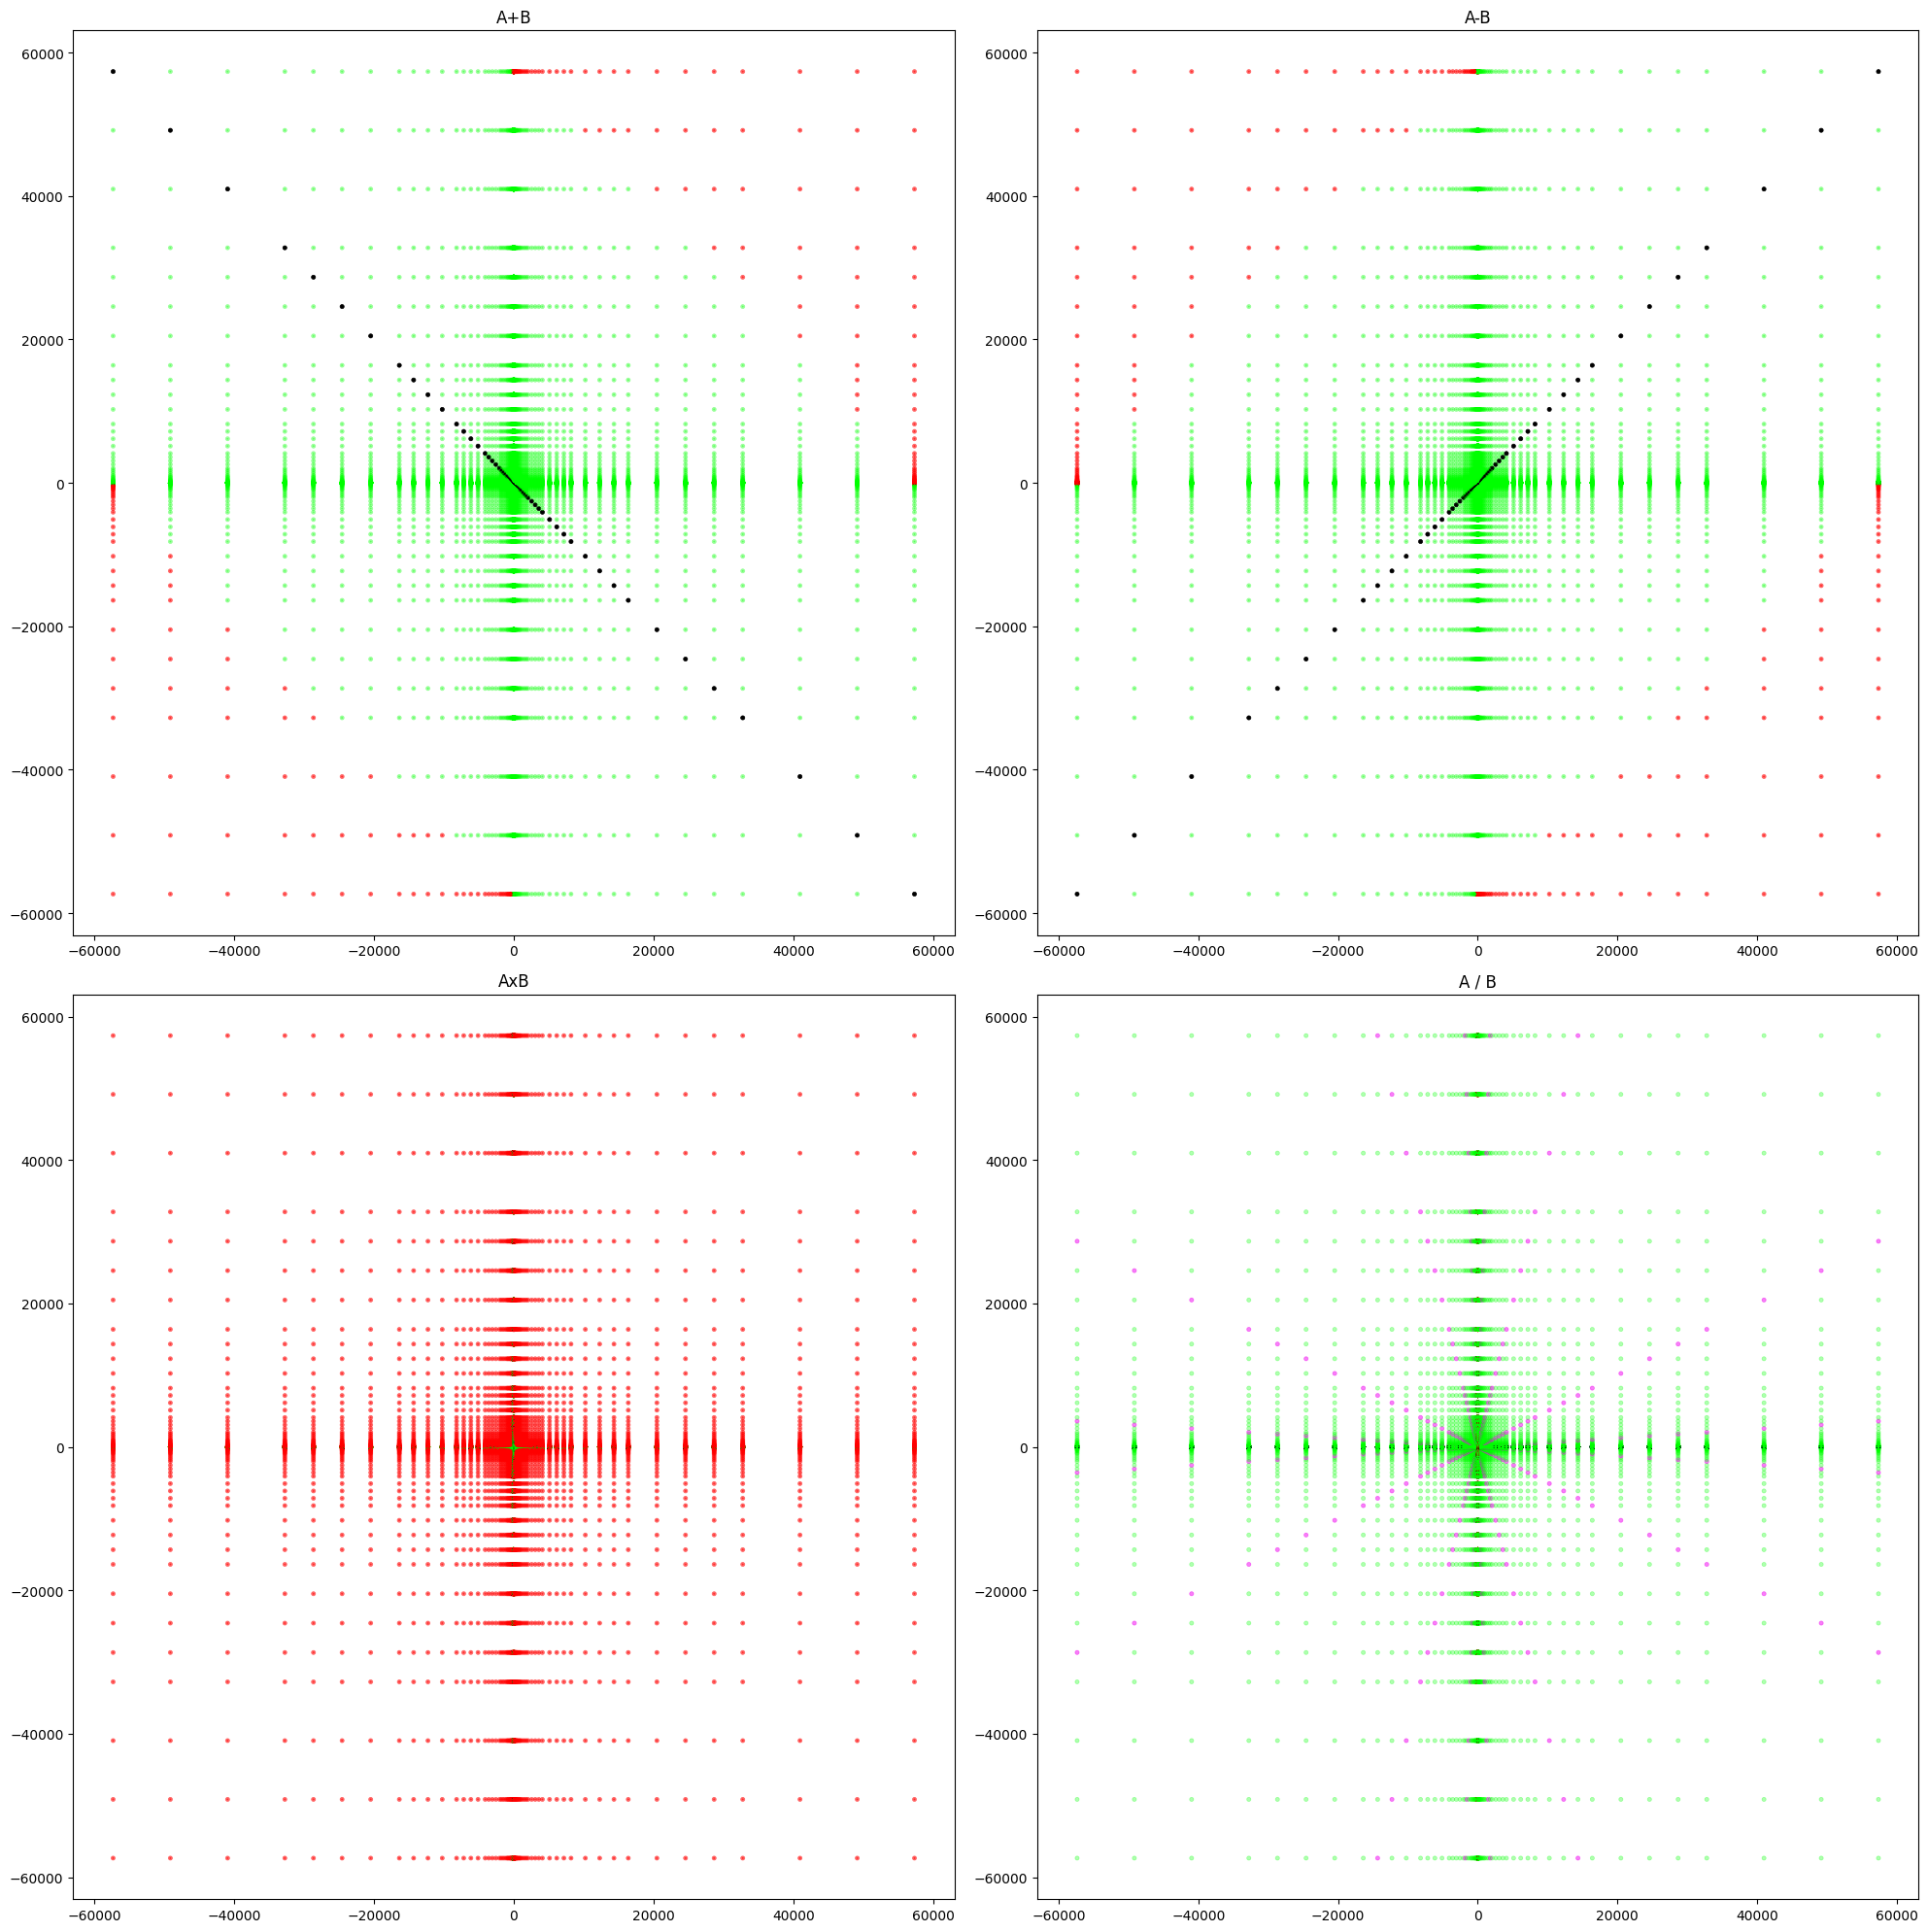

In [111]:
plot_basic_op_map(x, show_map2)

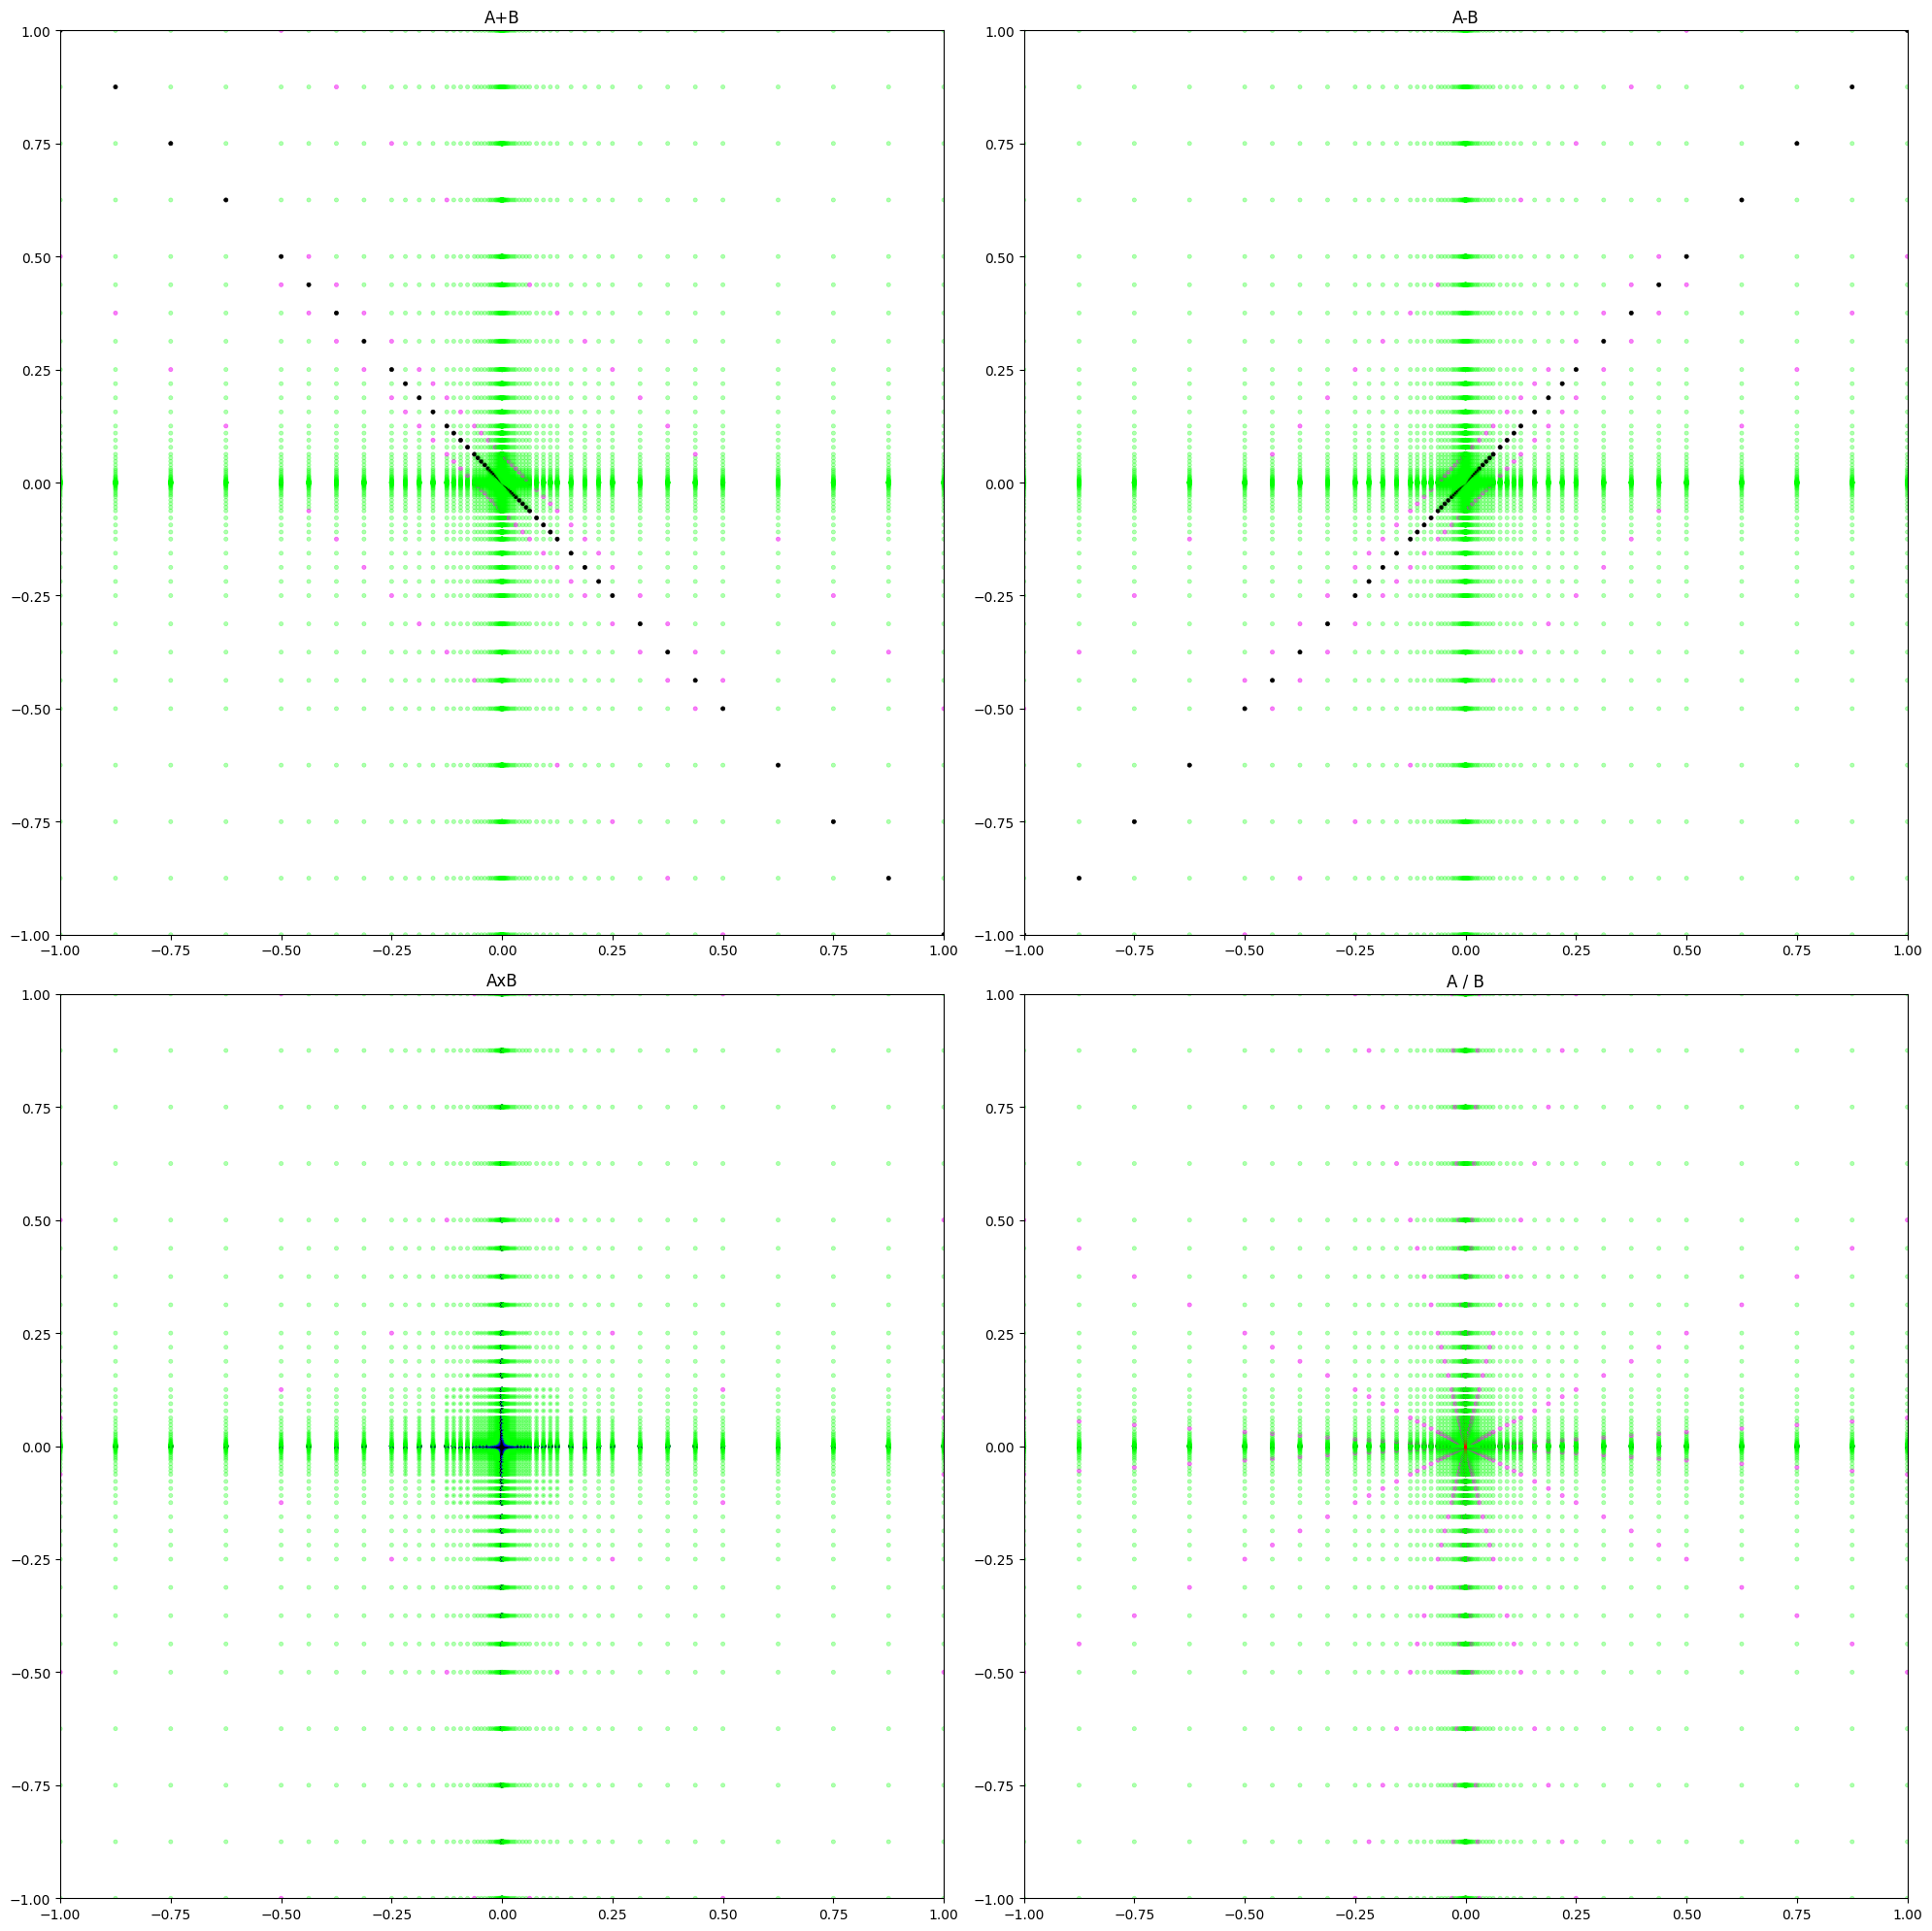

In [112]:
plot_basic_op_map(x, show_map2, limit=[-1,1])

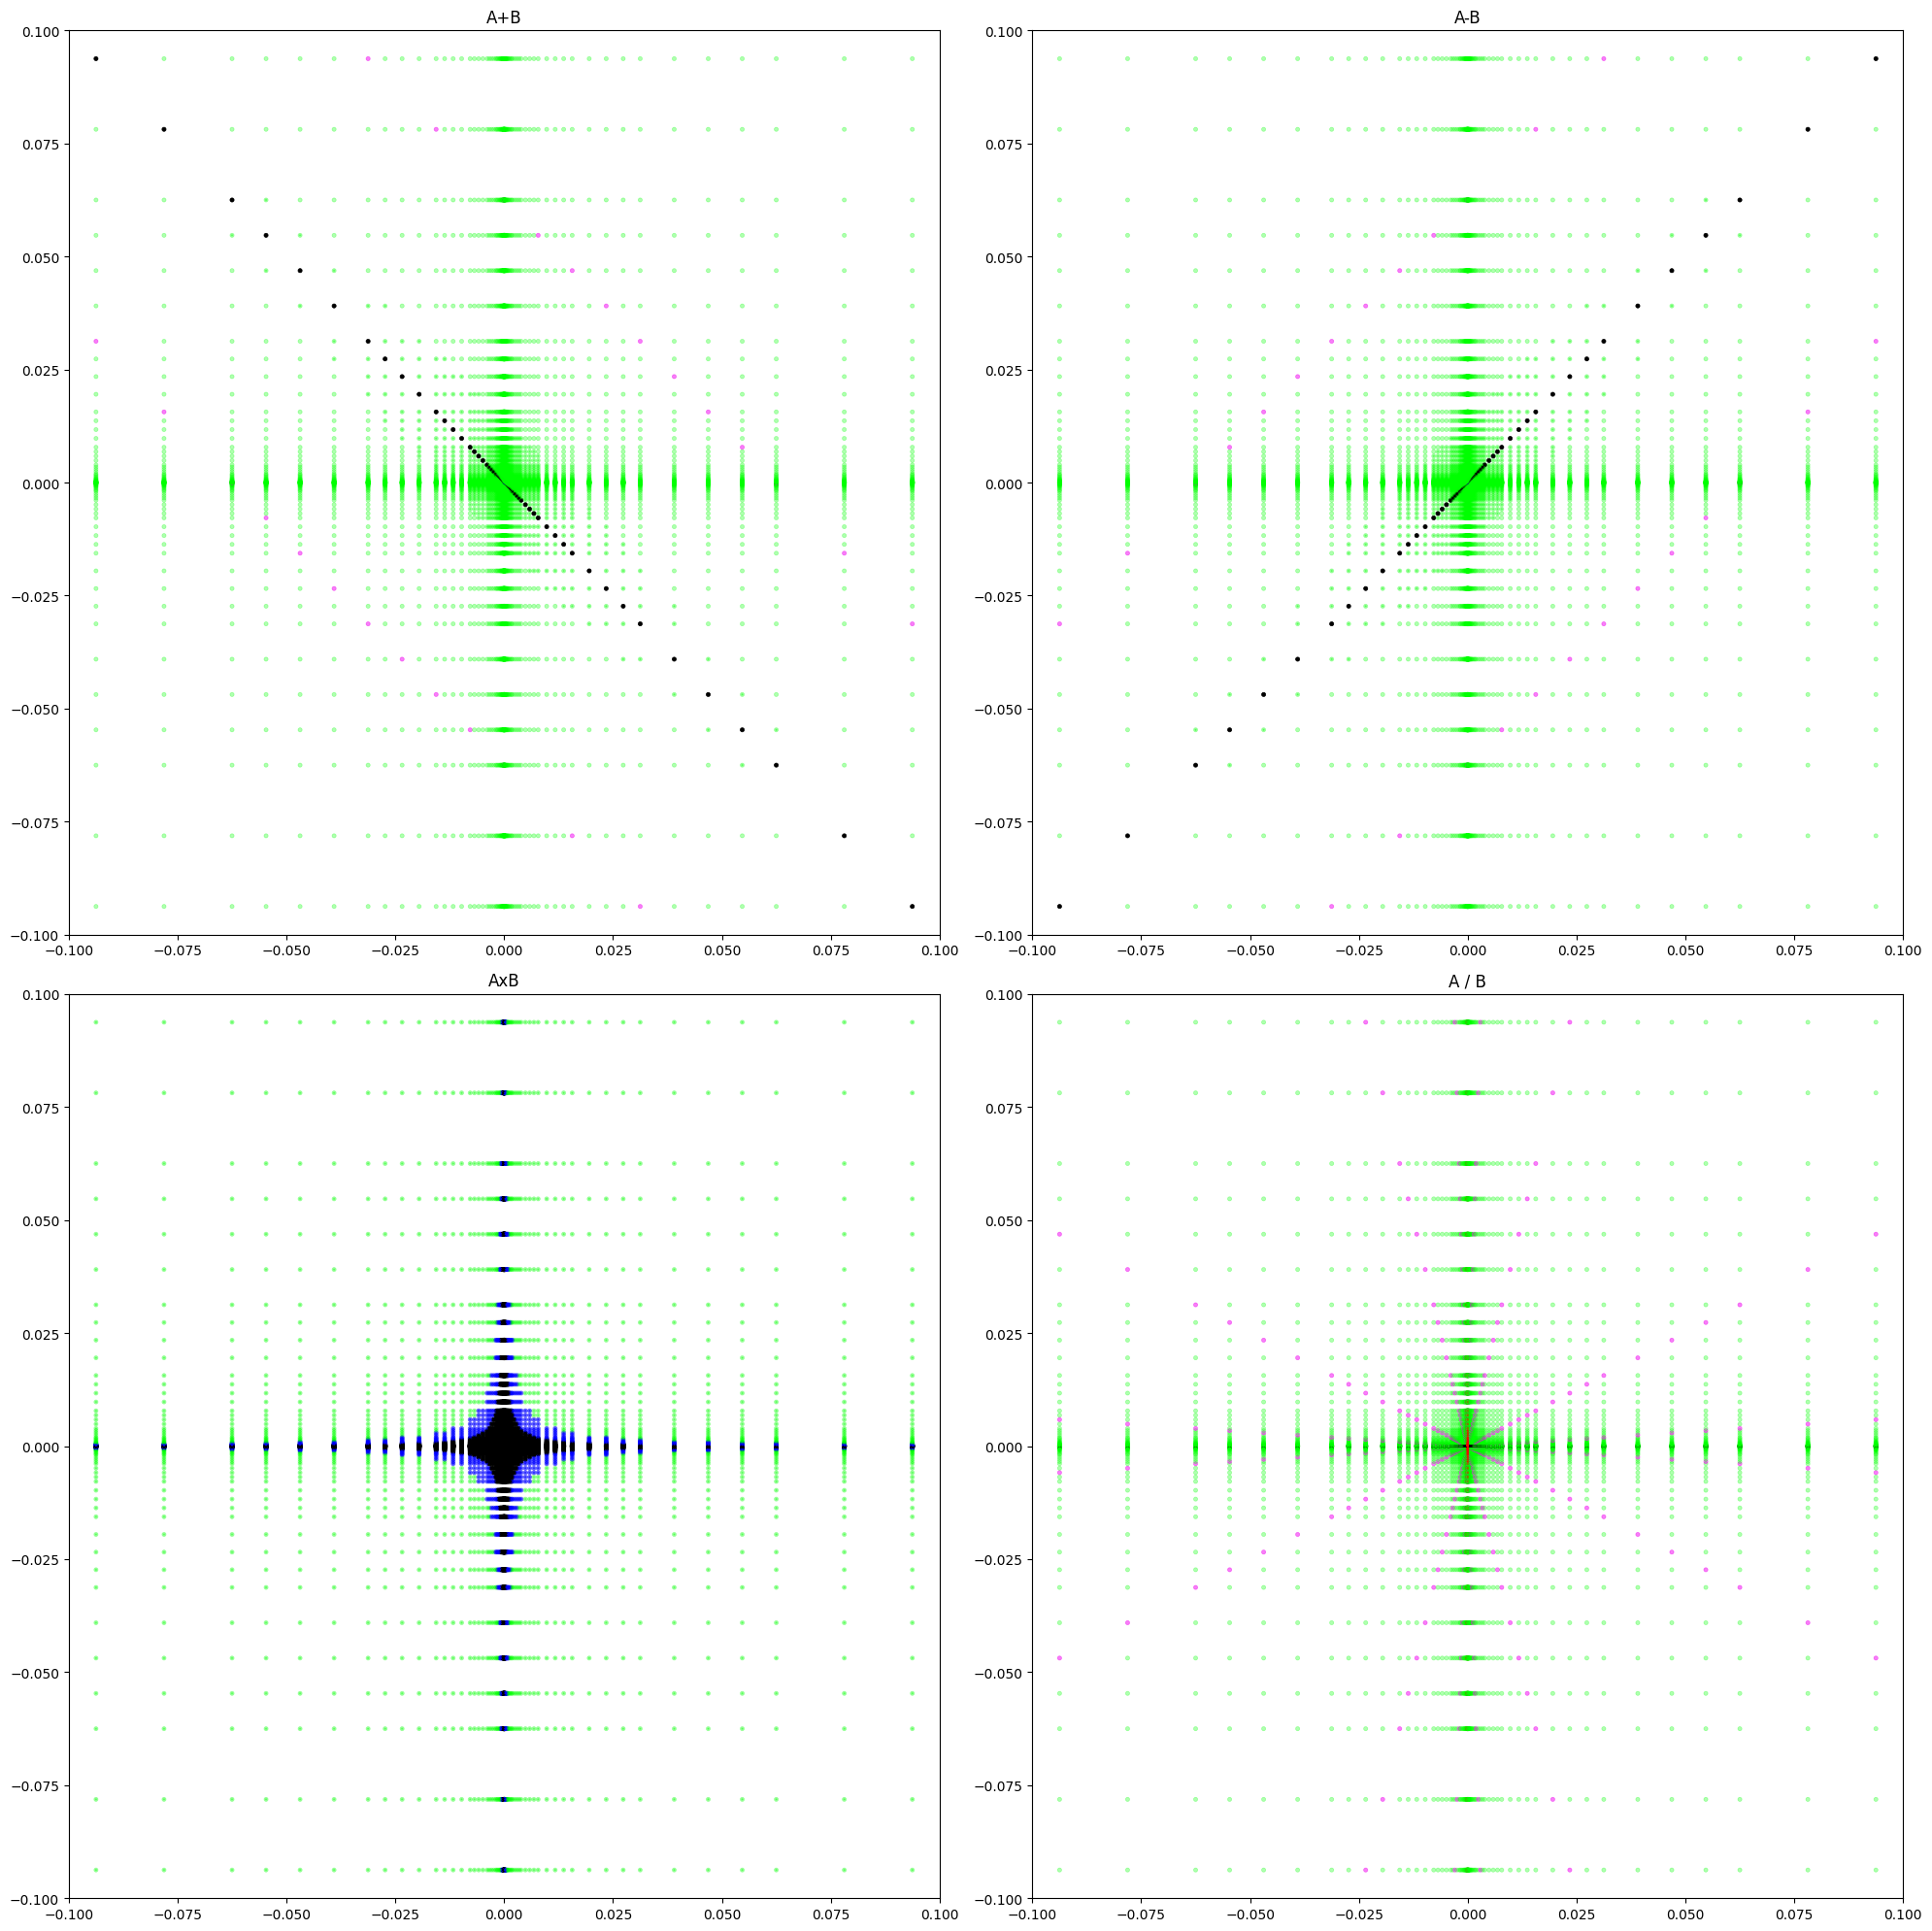

In [113]:
plot_basic_op_map(x, show_map2, limit=[-.1,.1])

对比FP8 E5M2在整个数值空间上性质更差，更不稳定。但对深度学习主要的数值范围[-1,+1]以及[-0.1,+0.1]，其解空间更性质更好，特别是针对乘法操作。

## 概率误差分析

数值误差分析和运算误差分析中，我们没有考虑实际大模型计算中的实际权重和激活数值分布。在本节我们假设操作数A和B都服从高斯分布，并在此基础上估算其结果落入不同误差区间的概率。

首先从高斯分布分别抽样操作数A和B。

In [131]:
x = .1*np.random.randn(10000)
x = np.sort(x)

y = .1*np.random.randn(10000)
y = np.sort(y)

In [154]:
def show_hist(xy, bins=200):
    N, bins, patches = plt.hist(xy,bins=bins)
    for b, p in zip(bins, patches):
        if abs(b) < 0.013671875:
            c = "#0000ff80"
            p.set_facecolor(c)
        if abs(b) < 0.001953125:
            c = "#000000FF"
            p.set_facecolor(c)
def show_hist2(xy, bins=200):
    N, bins, patches = plt.hist(xy,bins=bins)
    for b, p in zip(bins, patches):
        if abs(b) < 4.57763671875e-05:
            c = "#0000ff80"
            p.set_facecolor(c)
        if abs(b) < 1.52587890625e-05:
            c = "#000000FF"
            p.set_facecolor(c)
def plot_basic_op_hit(x, y, show_fn):
    plt.figure(figsize=(20,10))
    plt.subplot(2,2,1)
    xy = np.array([p+q for q in x for p in y])
    show_fn(xy)
    plt.title("A+B")
    
    plt.subplot(2,2,2)
    xy = np.array([p-q for q in x for p in y])
    show_fn(xy)
    plt.title("A-B")
    
    plt.subplot(2,2,3)
    xy = np.array([p*q for q in x for p in y])
    show_fn(xy)
    plt.title("AxB")
    
    plt.subplot(2,2,4)
    xy = np.array([p/q if q != 0 else 0 for q in x for p in y])
    show_fn(xy)
    plt.title("A/B")
    plt.tight_layout()

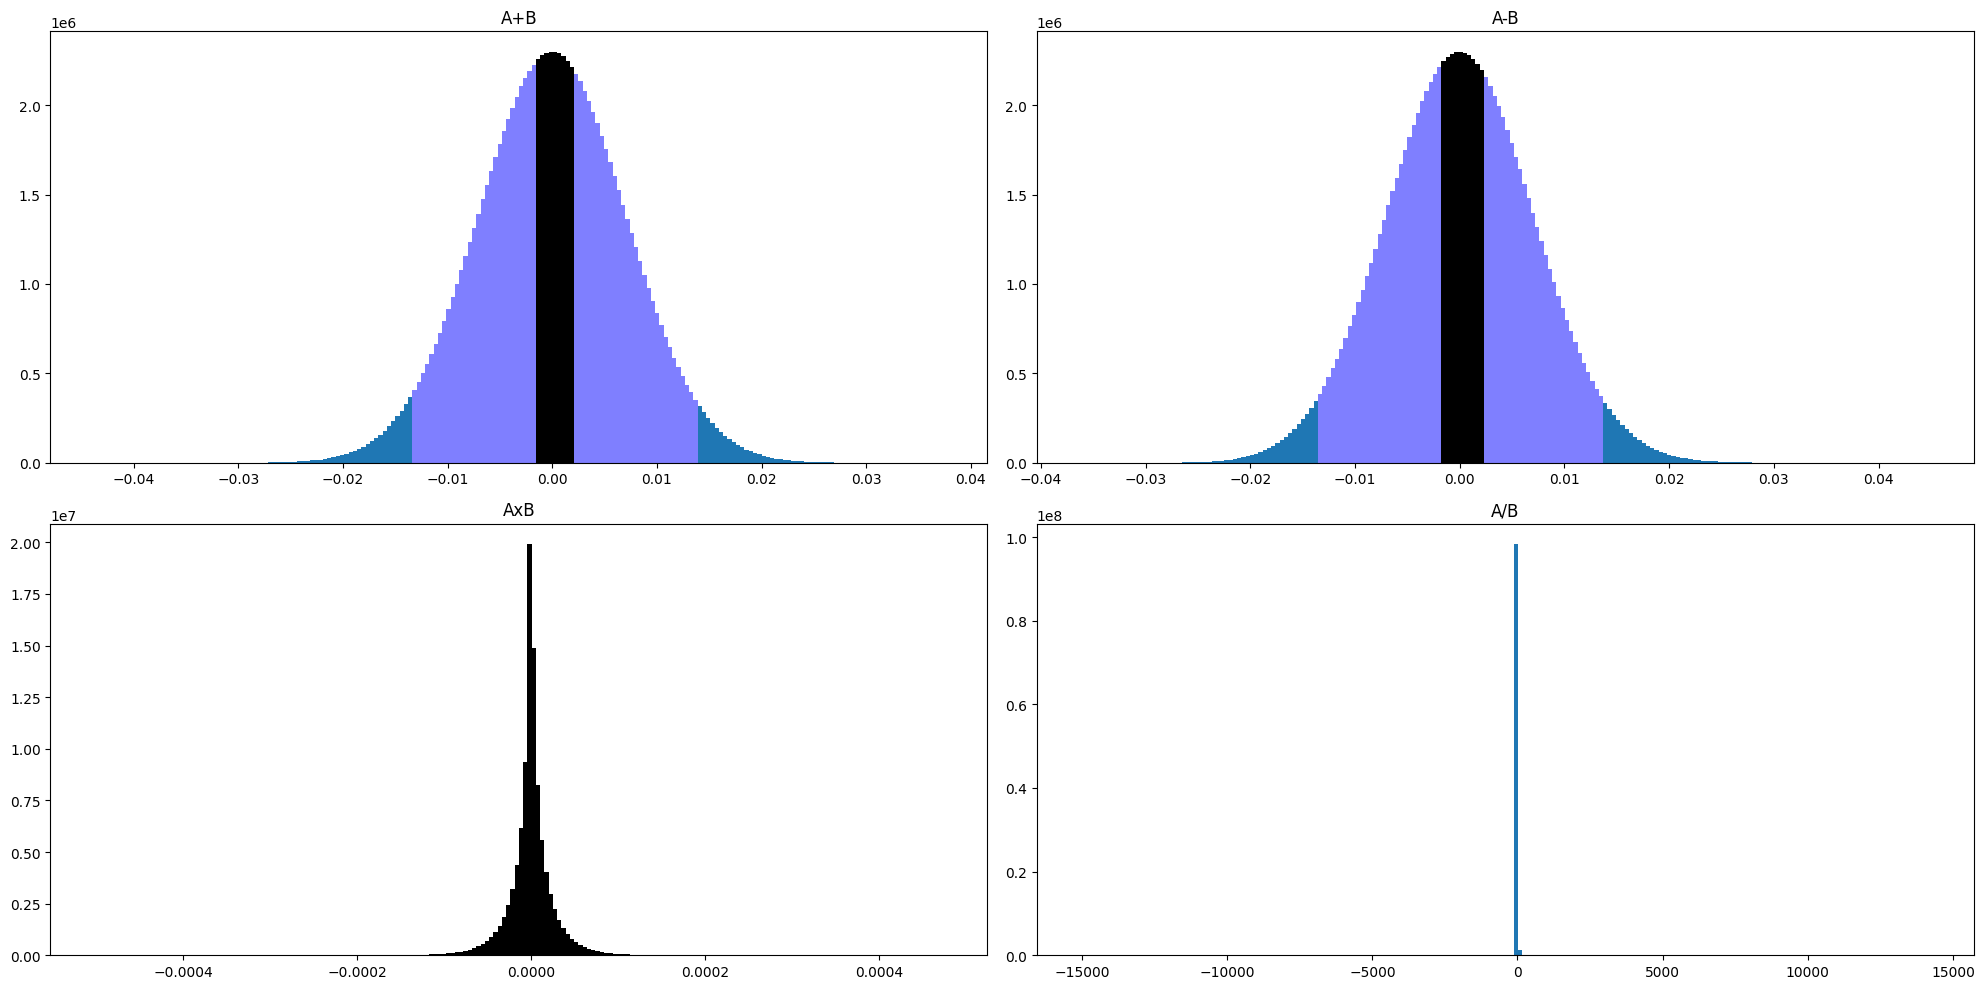

In [155]:
plot_basic_op_hit(x,y, show_hist)

可见，FP8 E4M3的乘法操作，导致大量结果都处于subnormal区间。再看下FP8 E5M2：

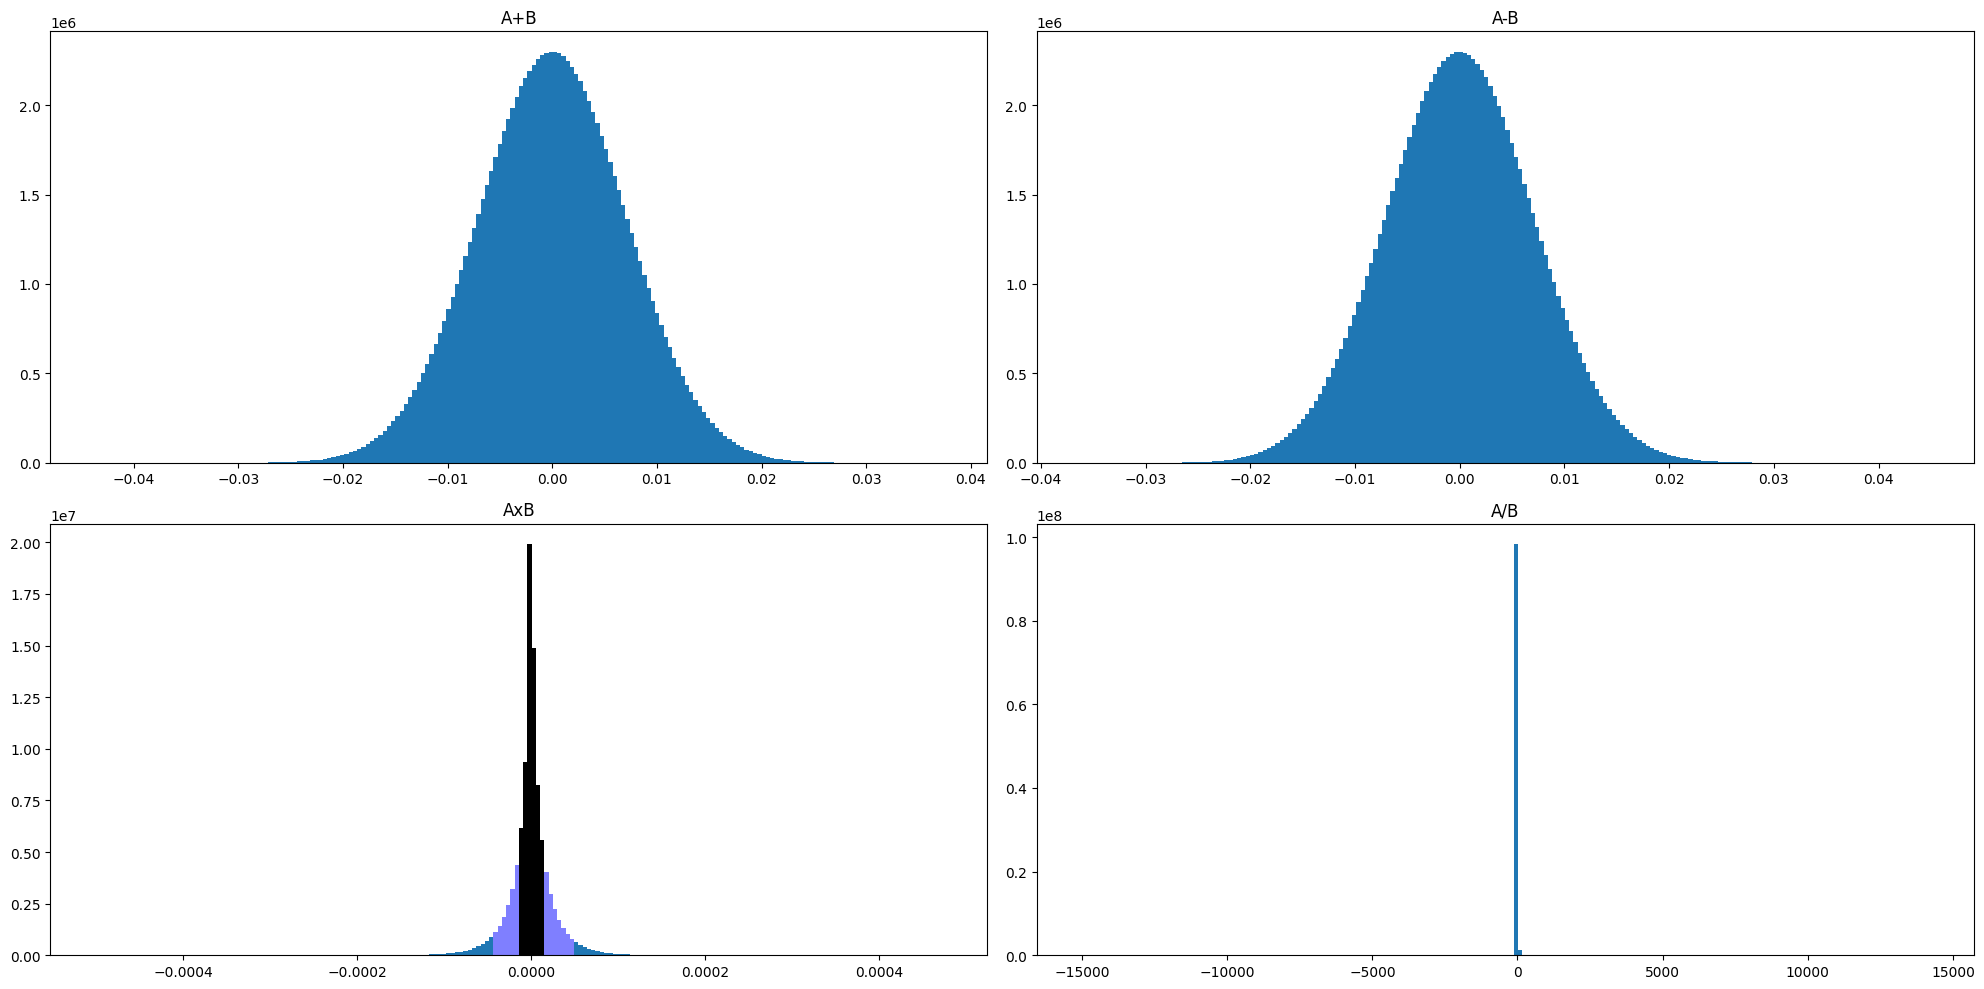

In [156]:
plot_basic_op_hit(x,y, show_hist2)

FP8 E5M2能够避免乘法操作的结果大量处于subnormal区间。

接下来我们看如何避免陷入subnormal区间，首先尝试把输入scale到更大的动态范围：

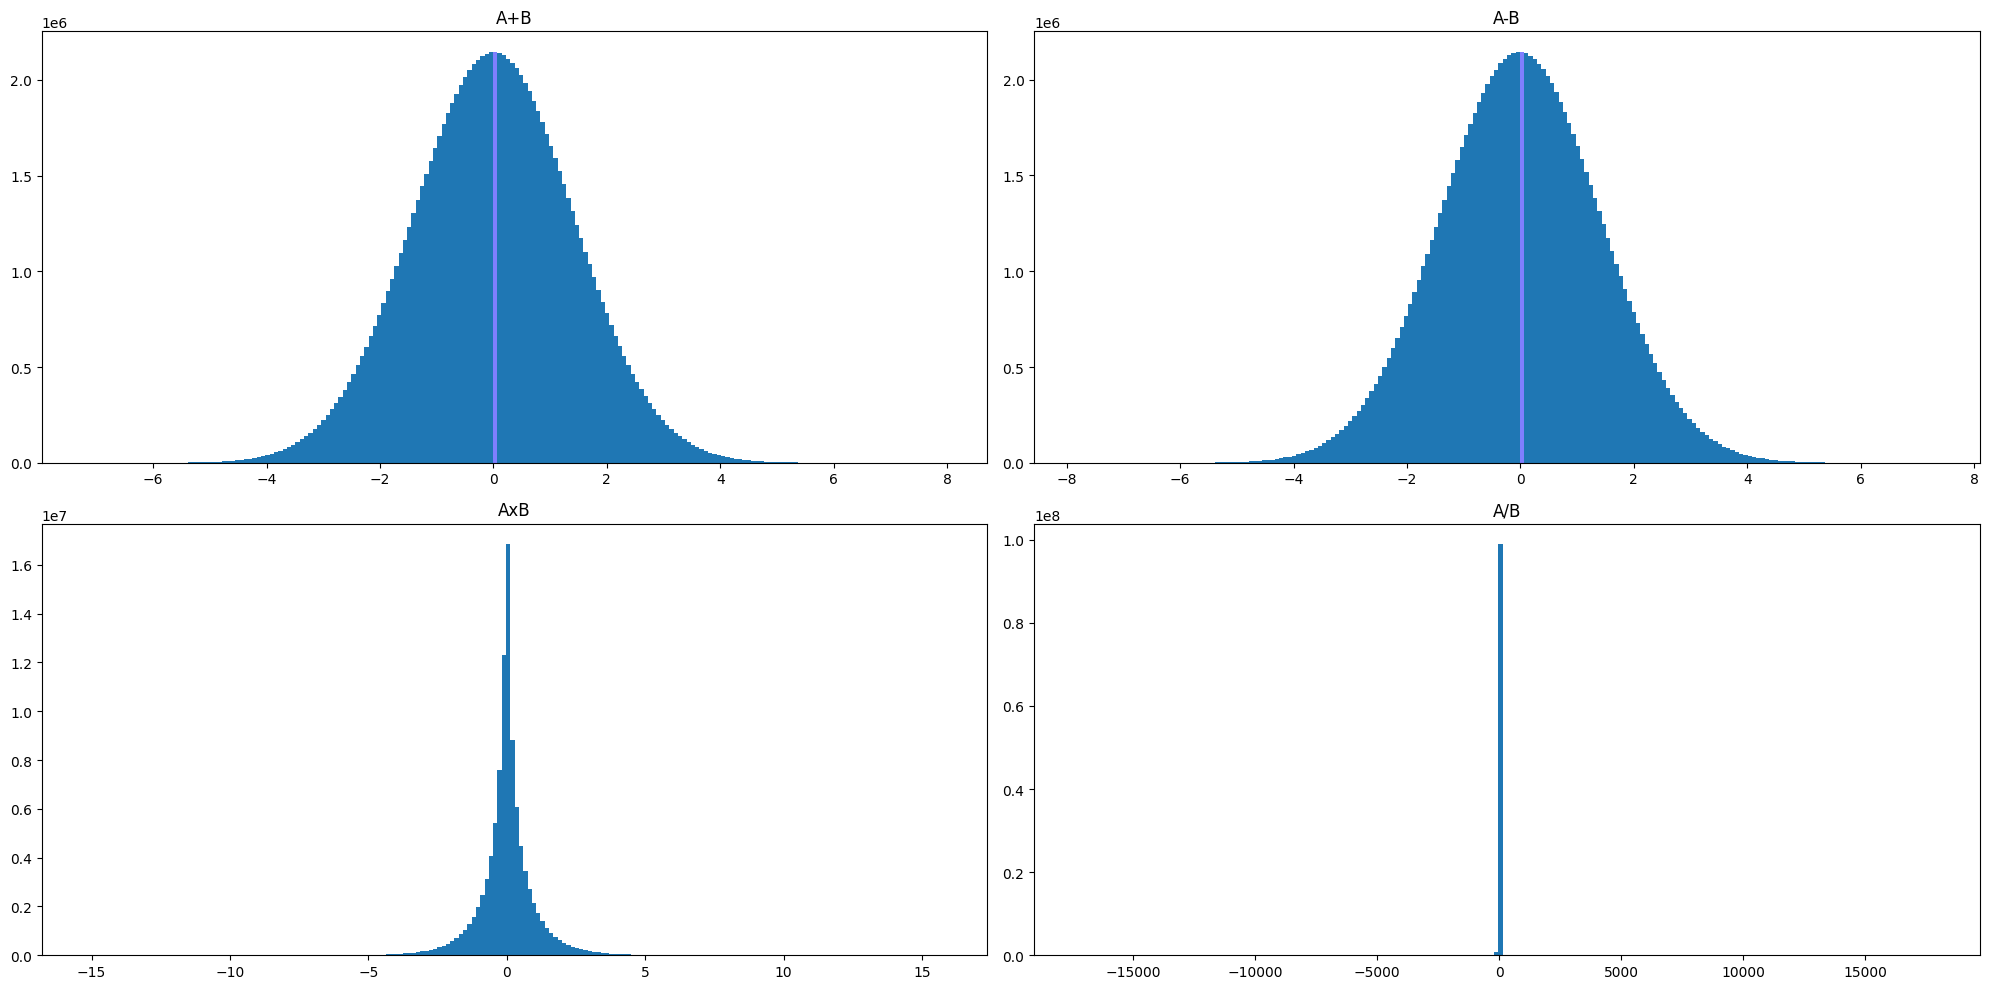

In [157]:
x = 1*np.random.randn(10000)
x = np.sort(x)

y = 1*np.random.randn(10000)
y = np.sort(y)

plot_basic_op_hit(x,y, show_hist)

我们发现，对输入进行scale之后，FP8 E4M3也能避免大量结果落入subnormal。接下来尝试FP8 E5M2是否在输入scale过小时也会陷入subnormal问题。发现随输入缩放10倍以上是，FP8 E5M2也会面临相同的问题。

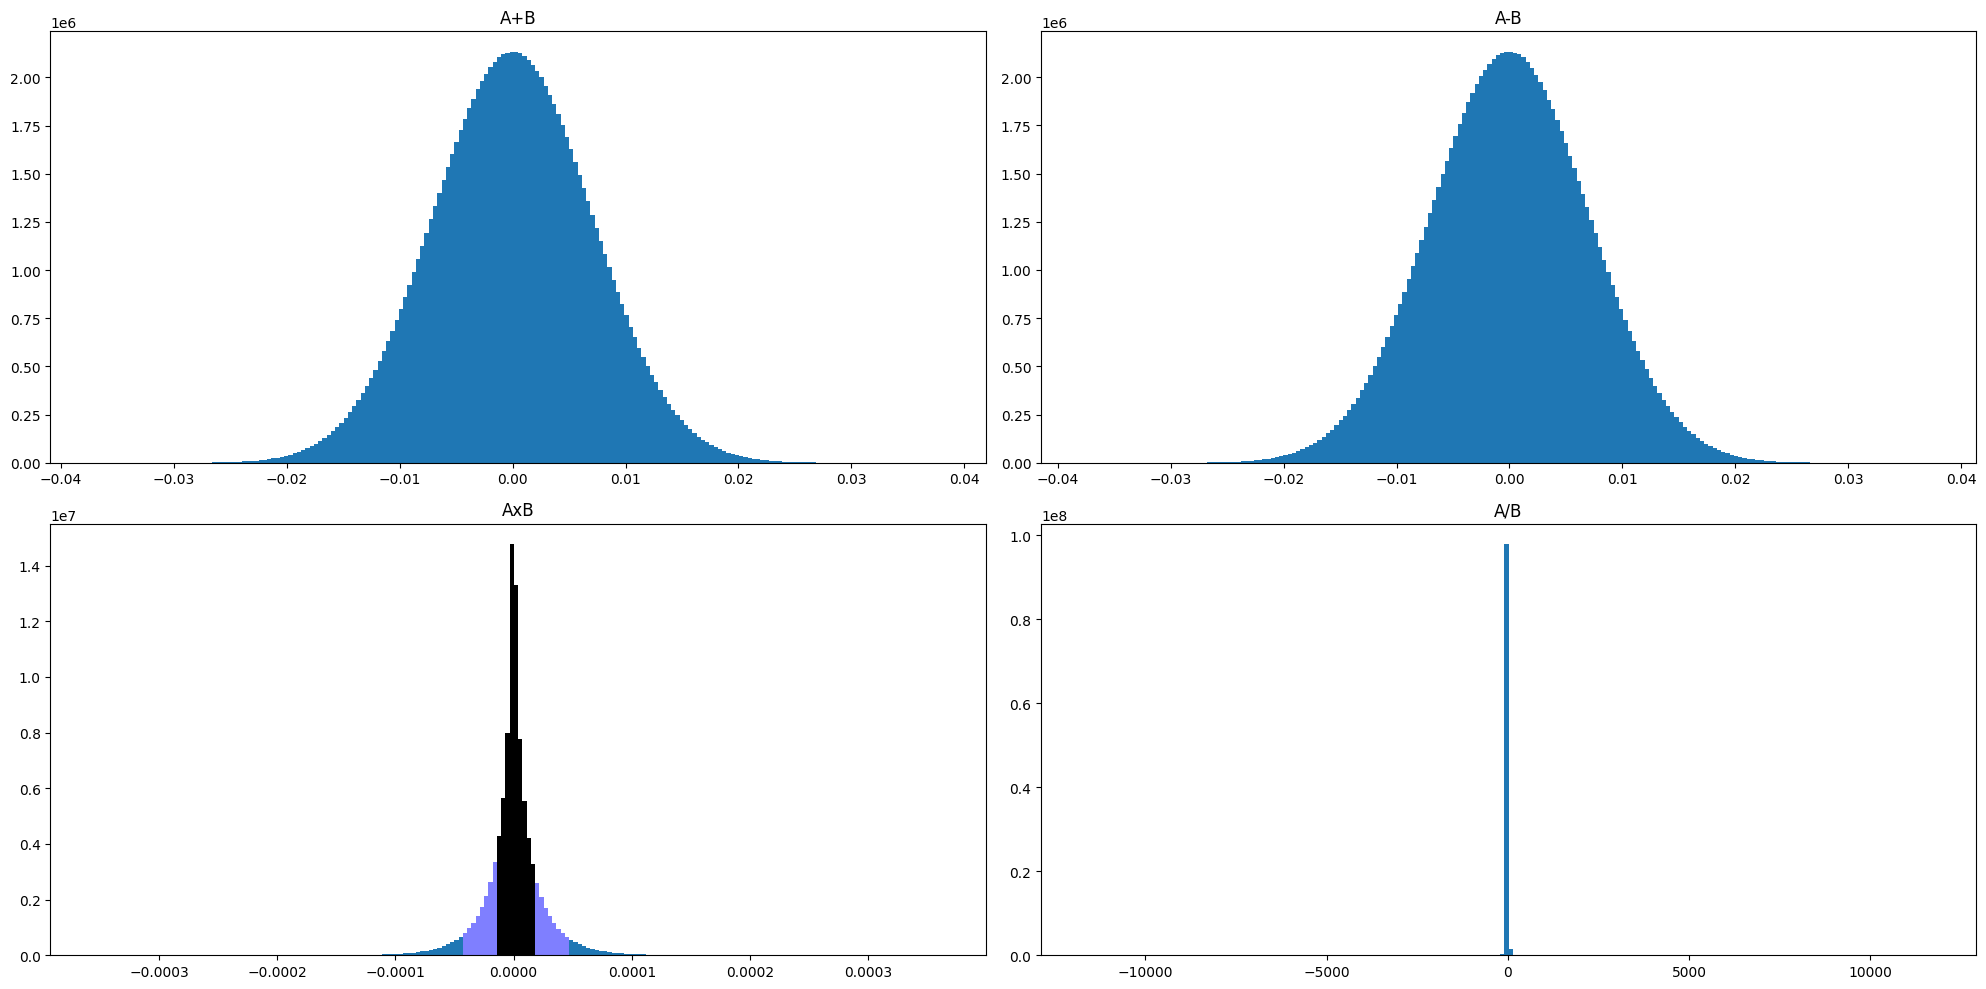

In [158]:
x = .005*np.random.randn(10000)
x = np.sort(x)

y = .005*np.random.randn(10000)
y = np.sort(y)

plot_basic_op_hit(x,y, show_hist2)

## GEMM误差分析

本节分析深度学习中最重要的GEMM操作受数值精度的影响。我们先选择两个[100x100]的矩阵相乘，用概率误差分析中的方法，分析结果数值分布。

Text(0.5, 1.0, 'FP8 E5M2')

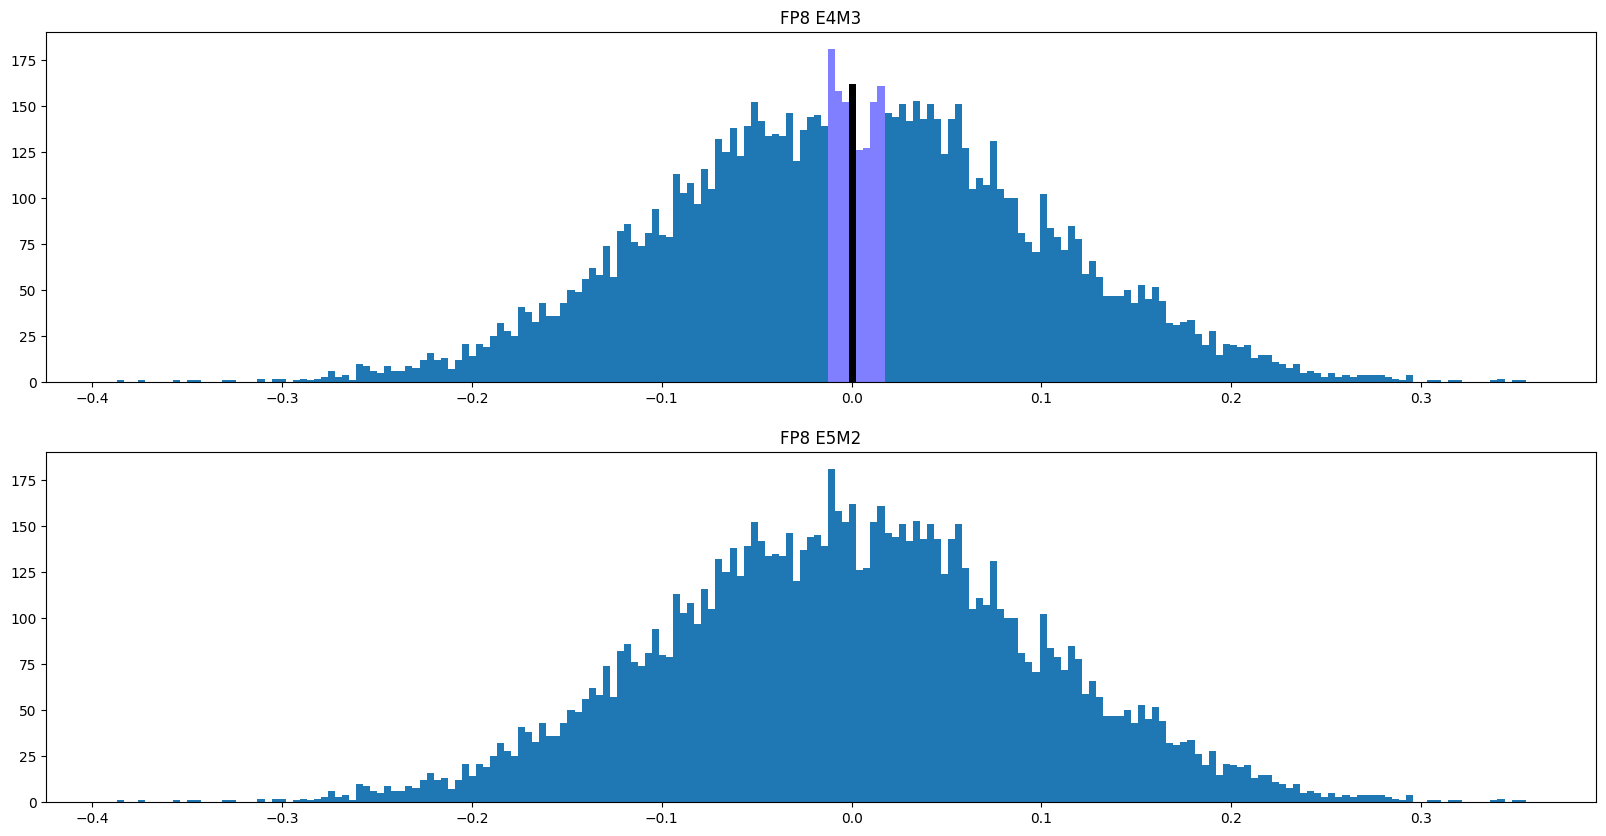

In [178]:
x = .1*np.random.randn(10000)
x = x.reshape([100,100])

y = .1*np.random.randn(10000)
y = y.reshape([100,100])

plt.figure(figsize=(20,10))
xy = np.dot(x,y)
plt.subplot(2,1,1)
show_hist(xy.reshape([10000]))
plt.title("FP8 E4M3")
plt.subplot(2,1,2)
show_hist2(xy.reshape([10000]))
plt.title("FP8 E5M2")

当输入矩阵中数值分布方差为0.1时，FP8 E4M3会出现一部分数值处于subnormal区间，并且部分数据处于zeroed区间。而FP8 E5M2的GEMM结果完全处于正常区间。如果缩放输入，将方差放大到1.0，则能够解决FP8 E4M3的数值稳定性问题。

Text(0.5, 1.0, 'FP8 E5M2')

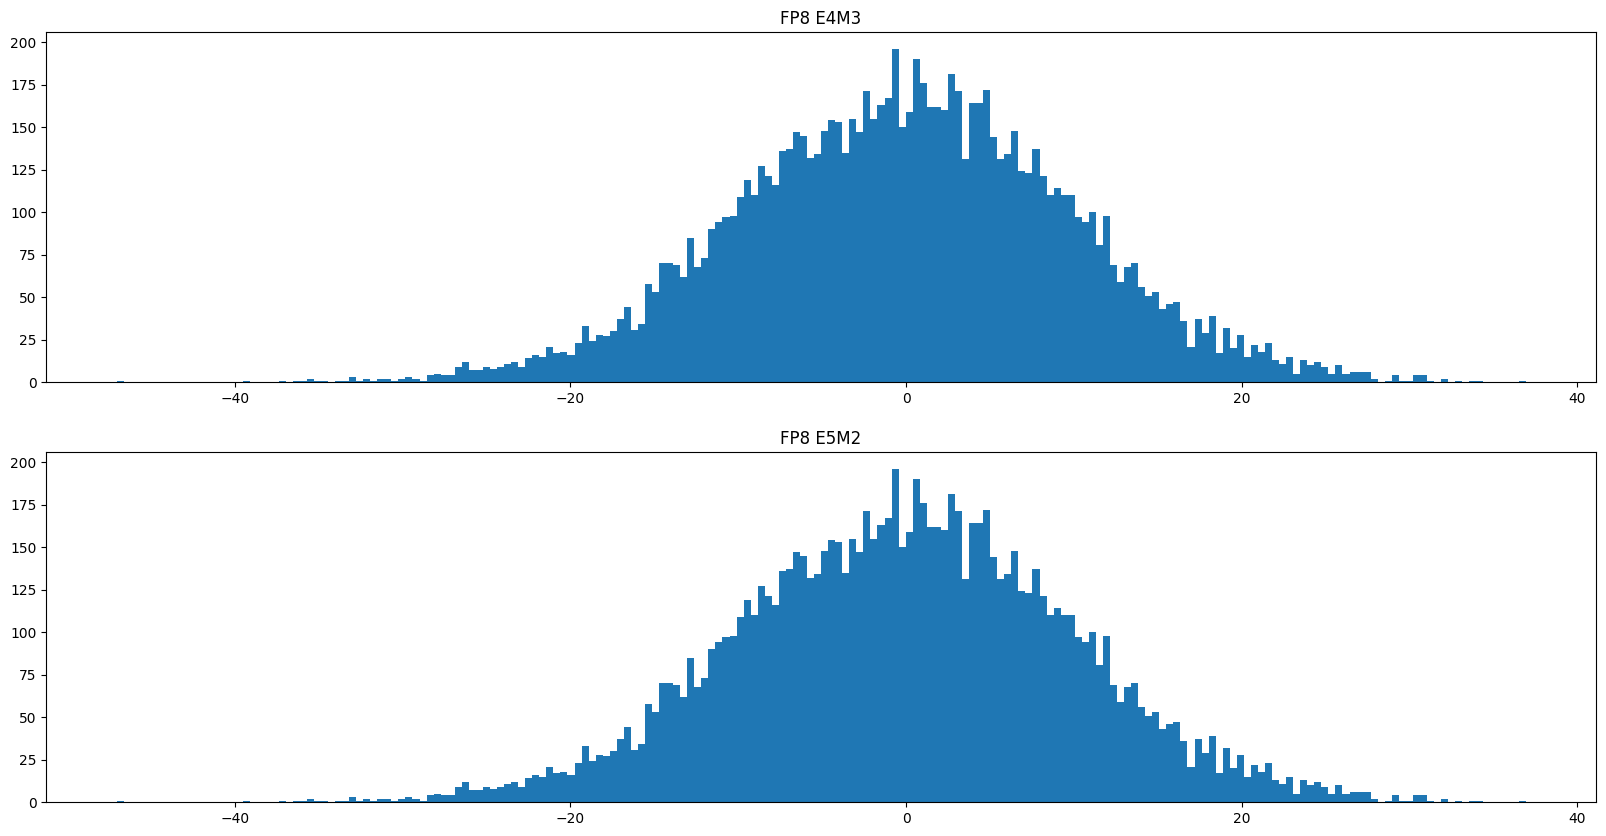

In [176]:
x = 1*np.random.randn(10000)
x = x.reshape([100,100])

y = 1*np.random.randn(10000)
y = y.reshape([100,100])

plt.figure(figsize=(20,10))
xy = np.dot(x,y)
plt.subplot(2,1,1)
show_hist(xy.reshape([10000]))
plt.title("FP8 E4M3")
plt.subplot(2,1,2)
show_hist2(xy.reshape([10000]))
plt.title("FP8 E5M2")

当进一步缩小输入数据方差，发现FP8 E4M3的GEMM结果分布出现大量zeroed区间的值。FP8 E5M2也开始收到影响：

Text(0.5, 1.0, 'FP8 E5M2')

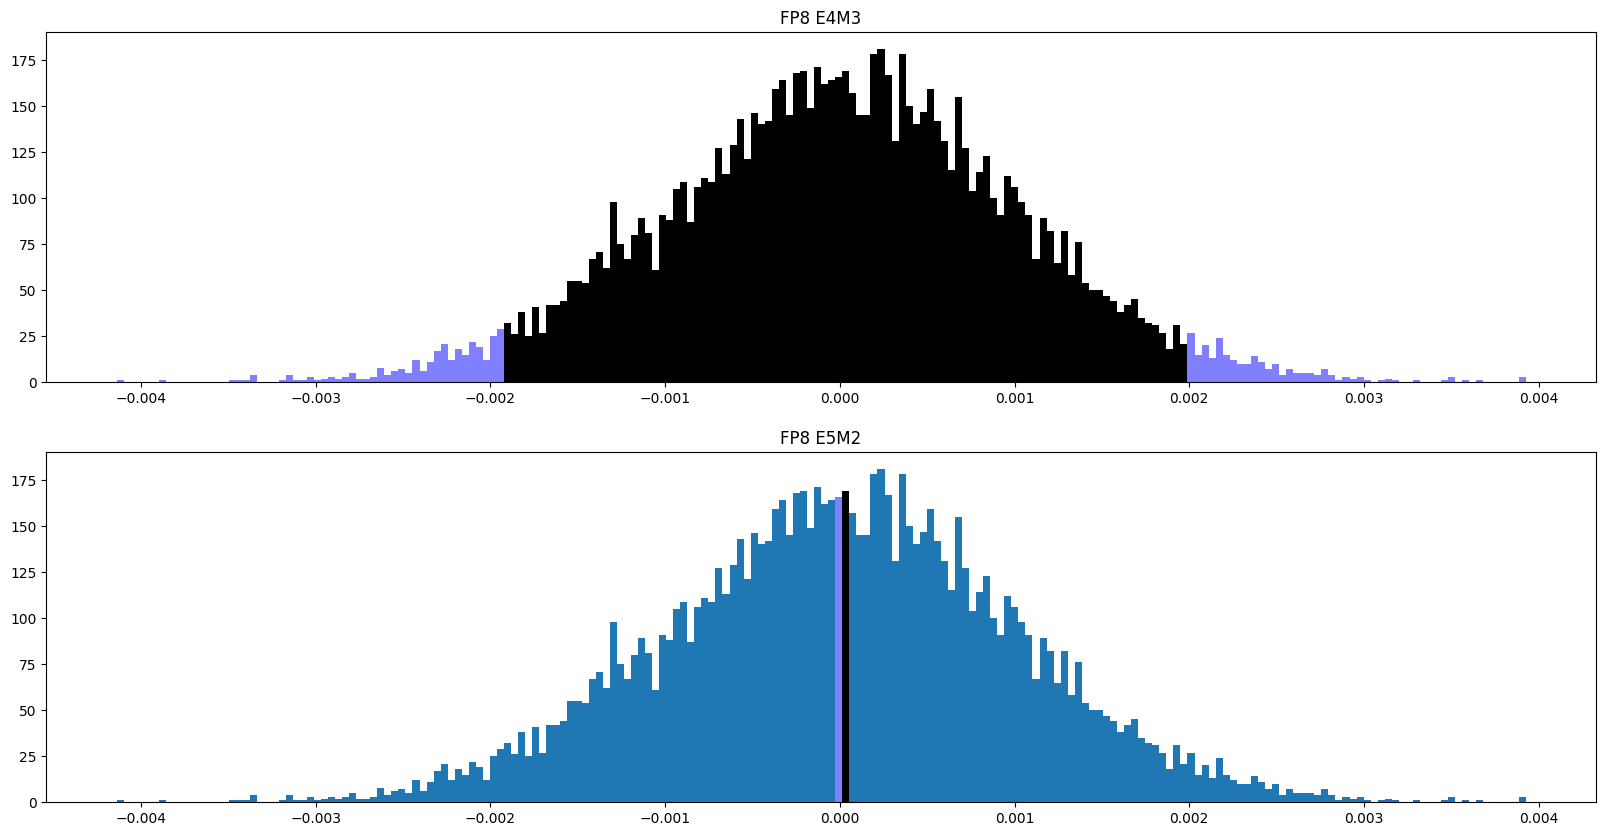

In [177]:
x = .01*np.random.randn(10000)
x = x.reshape([100,100])

y = .01*np.random.randn(10000)
y = y.reshape([100,100])

plt.figure(figsize=(20,10))
xy = np.dot(x,y)
plt.subplot(2,1,1)
show_hist(xy.reshape([10000]))
plt.title("FP8 E4M3")
plt.subplot(2,1,2)
show_hist2(xy.reshape([10000]))
plt.title("FP8 E5M2")

接下来进行扩大矩阵尺度的实验。通过不断改变矩阵的大小，发现当矩阵规模越大时，GEMM的输出分布约为稳定：

Text(0.5, 1.0, 'FP8 E5M2')

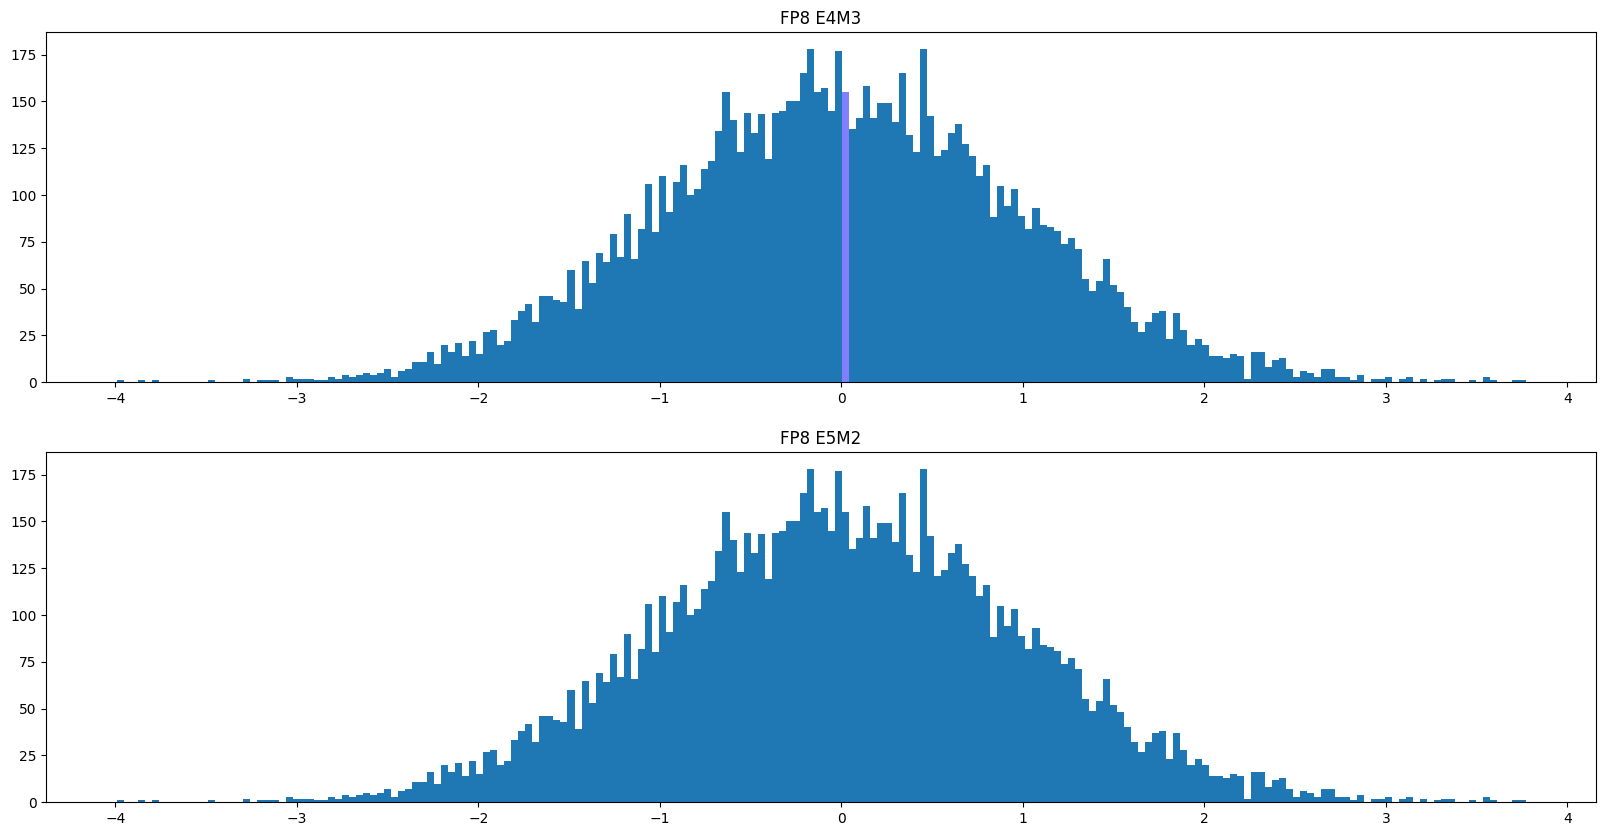

In [189]:
x = .1*np.random.randn(100000000)
x = x.reshape([10000,10000])

y = .1*np.random.randn(10000)
y = y.reshape([10000,1])

plt.figure(figsize=(20,10))
xy = np.dot(x,y)
plt.subplot(2,1,1)
show_hist(xy.reshape([10000]))
plt.title("FP8 E4M3")
plt.subplot(2,1,2)
show_hist2(xy.reshape([10000]))
plt.title("FP8 E5M2")

<span id="fn1">1:</span> https://en.wikipedia.org/wiki/Floating-point_arithmetic